# CR-39 Nuclear Track Detector — Optimized Data Analysis

**Experiment:** d + ¹³C, 125–50 µm Ta filter, W146, 5 hr, 40×, backside  
**Scan file:** `A20251217_13CD_125-50umTaFilter_W146_5hr_40x_backside_s0_B.cpsa`

This notebook performs a complete, end-to-end analysis of CR-39 scan data:
1. **Loads** the binary `.cpsa` file with a fast NumPy-based reader
2. **Explores** raw track distributions to guide cut selection
3. **Applies** quality cuts (diameter, contrast, eccentricity, spatial bounds)
4. **Visualizes** the filtered 2D track density with x/y projections
5. **Computes** signal and background track counts with area-scaling subtraction
6. **Summarizes** all key statistics in one place

> All plots are saved to `plots/` in the analysis directory.

## 1. Imports

In [ ]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import struct

# ── Numerical & data ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Plotting ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LogNorm, SymLogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator

# ── Progress bar (optional) ───────────────────────────────────────────────────
try:
    from tqdm import tqdm
except ImportError:
    def tqdm(x, *args, **kwargs):
        return x

# ── Global plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'figure.dpi': 150,
})

print('Imports OK')

## 2. Configuration

Edit **only this cell** to change the file path, quality cuts, or region bounds.  
Everything downstream will update automatically.

In [ ]:
CPSA_FILE = (
    "../CR-39_data/A20260413_13CD_125-50umTaFilter_W75_5hr_40x_backside_s0.cpsa"
)

# ── Quality cuts (applied during file parsing — very fast) ─────────────────────
  # UPDATE: Set D_MAX to 13.0 um (originally 17.5 um). This filters out larger
  # background noise (like dust, defects, or slow heavy ions) to isolate the 5.6 MeV protons.
D_MIN,  D_MAX  =  2.0, 13.0   # Track diameter bounds   (µm)
E_MIN,  E_MAX  =  0,   15     # Eccentricity bounds     (raw units, int8)
C_MIN,  C_MAX  =  0,   20     # Normal contrast bounds  (raw units, int8)
X_MIN,  X_MAX  = -2.5,  2.5   # Spatial x bounds        (cm)
Y_MIN,  Y_MAX  = -2.5,  2.5   # Spatial y bounds        (cm)

# ── Signal region (rectangular, drawn in red) ─────────────────────────────────
SIG_XMIN, SIG_XMAX = -1.5,  1.5
SIG_YMIN, SIG_YMAX = -1.8,  1.4   # y_min matched to the region used in the
                                  # background-subtraction cell (A_sig = 9.6 cm2)

# ── Background strip (same x width, above signal region, drawn in blue) ────────
BG_XMIN,  BG_XMAX  = -1.37,  1.47
BG_YMIN,  BG_YMAX  =  1.50,  1.89

# ── Histogram binning ─────────────────────────────────────────────────────────
BINS_XY = 100   # 2D spatial histogram bins per axis
BINS_D  = 100   # Diameter distribution bins
BINS_R  = 100   # Radial distribution bins
BINS_C  =  50   # Contrast distribution bins

# ── Output directory for saved figures ───────────────────────────────────────
PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

print(f'Config OK — saving plots to "{PLOT_DIR}/')


## 3. Optimized ScanData Reader

Key optimisations over the original `reader.py`:
- **Bulk NumPy reads** (`np.frombuffer`) replace per-element `struct.unpack` calls — up to ~20× faster on large scans
- **Vectorised filtering** with boolean NumPy masks instead of Python `if` per track
- **Single DataFrame construction** at the end (no incremental `pd.concat` inside the loop)
- Removed unused `frame_buffer_size` / `track_buffer_size` paging parameters

In [4]:
class ScanData:
    """
    Fast reader for CR-39 CPSA binary scan files.

    Parameters
    ----------
    path       : str   – Path to the .cpsa file.
    d_bounds   : (min, max) – Diameter filter in µm.
    e_bounds   : (min, max) – Eccentricity filter (raw int8).
    c_bounds   : (min, max) – Normal contrast filter (raw int8).
    a_bounds   : (min, max) – Average contrast filter (raw int8).
    x_bounds   : (min, max) – Spatial x filter in cm.
    y_bounds   : (min, max) – Spatial y filter in cm.

    Attributes
    ----------
    header  : dict       – Scan metadata (pixel size, frame dimensions, …)
    frames  : DataFrame  – Per-frame info (position, num_tracks, focus, …)
    tracks  : DataFrame  – Track data (d, x, y, e, c, a, frame_number)
    trailer : str        – ASCII trailer appended by the scanner software.
    """

    def __init__(self, path,
                 d_bounds=(0, np.inf),
                 e_bounds=(0, np.inf),
                 c_bounds=(0, np.inf),
                 a_bounds=(0, np.inf),
                 x_bounds=(-np.inf, np.inf),
                 y_bounds=(-np.inf, np.inf)):
        self.header  = {}
        self.frames  = None
        self.tracks  = None
        self.trailer = ''

        with open(path, 'rb') as f:
            self._parse_header(f)
            self._parse_data(f, d_bounds, e_bounds, c_bounds,
                             a_bounds, x_bounds, y_bounds)
            self._parse_trailer(f)

    # ── Helper: read a little-endian int32 ────────────────────────────────────
    @staticmethod
    def _ri(f):
        return struct.unpack('<i', f.read(4))[0]

    @staticmethod
    def _rf(f):
        return struct.unpack('<f', f.read(4))[0]

    # ── Header (48 bytes) ─────────────────────────────────────────────────────
    def _parse_header(self, f):
        ri, rf = self._ri, self._rf
        ps = 1e-4 * rf(f)  # pixel size in cm — read after version/dim fields below

        # Re-read in correct order (version_number is field 0)
        f.seek(0)  # rewind
        h = {
            'version_number':     ri(f),
            'num_x_frames':       ri(f),
            'num_y_frames':       ri(f),
            'num_bins':           ri(f),
            'pixel_size':   1e-4 * rf(f),   # cm per pixel
            'pixels_per_bin':     rf(f),
            'border_limit':       ri(f),
            'contrast_limit':     ri(f),
            'eccentricity_limit': ri(f),
            'M':                  ri(f),
            'frame_width':        ri(f),    # in pixels — converted below
            'frame_height':       ri(f),    # in pixels — converted below
        }
        ps = h['pixel_size']
        h['frame_width']  *= ps   # → cm
        h['frame_height'] *= ps   # → cm
        self.header = h

    # ── Frame + track data ────────────────────────────────────────────────────
    def _parse_data(self, f, d_bounds, e_bounds, c_bounds,
                   a_bounds, x_bounds, y_bounds):
        ps = self.header['pixel_size']
        fw = self.header['frame_width']
        fh = self.header['frame_height']
        num_frames = self.header['num_x_frames'] * self.header['num_y_frames']

        frame_rows = []   # collect frame metadata
        track_chunks = [] # collect filtered track arrays (one ndarray per frame)

        for _ in tqdm(range(num_frames), desc='Reading frames', unit='fr'):
            # ── Frame header (28 bytes) ────────────────────────────────────
            number      = struct.unpack('<i', f.read(4))[0]
            x_pos       = 1e-5 * struct.unpack('<i', f.read(4))[0]  # cm
            y_pos       = 1e-5 * struct.unpack('<i', f.read(4))[0]  # cm
            num_tracks  = struct.unpack('<i', f.read(4))[0]
            f.read(12)   # skip 3 unused int32 fields
            focus       = 1e-2 * struct.unpack('<i', f.read(4))[0]  # µm
            xi          = struct.unpack('<i', f.read(4))[0]          # x index
            yi          = struct.unpack('<i', f.read(4))[0]          # y index

            frame_rows.append((number, x_pos, y_pos, num_tracks,
                               focus, xi, yi))

            if num_tracks == 0:
                continue

            # ── Bulk-read all six track arrays at once ─────────────────────
            # Layout in file: d[n], e[n], c[n], a[n], x[n], y[n]
            d_raw = np.frombuffer(f.read(2 * num_tracks), dtype='<i2')  # int16 → µm after scale
            e_raw = np.frombuffer(f.read(num_tracks),     dtype='<i1')  # int8  eccentricity
            c_raw = np.frombuffer(f.read(num_tracks),     dtype='<i1')  # int8  normal contrast
            a_raw = np.frombuffer(f.read(num_tracks),     dtype='<i1')  # int8  average contrast
            x_raw = np.frombuffer(f.read(2 * num_tracks), dtype='<i2')  # int16 pixel position
            y_raw = np.frombuffer(f.read(2 * num_tracks), dtype='<i2')  # int16 pixel position

            # ── Unit conversion (vectorised) ───────────────────────────────
            d_um = 100.0 * d_raw * ps         # diameter in µm
            x_cm = x_pos - 0.5*fw + x_raw*ps  # absolute x in cm
            y_cm = y_pos - 0.5*fh + y_raw*ps  # absolute y in cm

            # ── Vectorised quality + spatial filter ────────────────────────
            mask = (
                (d_um  >= d_bounds[0]) & (d_um  <= d_bounds[1]) &
                (e_raw >= e_bounds[0]) & (e_raw <= e_bounds[1]) &
                (c_raw >= c_bounds[0]) & (c_raw <= c_bounds[1]) &
                (a_raw >= a_bounds[0]) & (a_raw <= a_bounds[1]) &
                (x_cm  >= x_bounds[0]) & (x_cm  <= x_bounds[1]) &
                (y_cm  >= y_bounds[0]) & (y_cm  <= y_bounds[1])
            )

            n_pass = mask.sum()
            if n_pass == 0:
                continue

            # Pack selected tracks into a (n_pass × 7) float64 array
            chunk = np.empty((n_pass, 7), dtype=np.float64)
            chunk[:, 0] = number          # frame_number (stored as float, cast later)
            chunk[:, 1] = d_um[mask]      # d  [µm]
            chunk[:, 2] = x_cm[mask]      # x  [cm]
            chunk[:, 3] = y_cm[mask]      # y  [cm]
            chunk[:, 4] = e_raw[mask]     # e  (eccentricity)
            chunk[:, 5] = c_raw[mask]     # c  (normal contrast)
            chunk[:, 6] = a_raw[mask]     # a  (average contrast)
            track_chunks.append(chunk)

        # ── Build DataFrames once at the end (avoids costly pd.concat in loop) ─
        self.frames = pd.DataFrame(frame_rows, columns=[
            'number', 'x_position', 'y_position', 'num_tracks',
            'focus', 'x_position_index', 'y_position_index'
        ])

        if track_chunks:
            arr = np.vstack(track_chunks)
            self.tracks = pd.DataFrame(arr, columns=[
                'frame_number', 'd', 'x', 'y', 'e', 'c', 'a'
            ])
            # Restore compact dtypes to save memory
            self.tracks['frame_number'] = self.tracks['frame_number'].astype(np.int32)
            self.tracks[['e', 'c', 'a']] = self.tracks[['e', 'c', 'a']].astype(np.int8)
            self.tracks[['d', 'x', 'y']] = self.tracks[['d', 'x', 'y']].astype(np.float32)
        else:
            self.tracks = pd.DataFrame(
                columns=['frame_number', 'd', 'x', 'y', 'e', 'c', 'a'])

    # ── Trailer (ASCII metadata appended by scanner) ──────────────────────────
    def _parse_trailer(self, f):
        f.read(4)  # skip 4-byte separator
        self.trailer = f.read().decode('latin-1')

    def __repr__(self):
        h = self.header
        return (
            f'ScanData  {h["num_x_frames"]}×{h["num_y_frames"]} frames  '
            f'pixel={h["pixel_size"]*1e4:.4f} µm  '
            f'tracks={len(self.tracks):,}'
        )


print('ScanData class defined')

ScanData class defined


## 4. Load Data

In [5]:
# Load the CPSA file.  All quality + spatial cuts are applied during parsing.
data = ScanData(
    CPSA_FILE,
    d_bounds=(D_MIN, D_MAX),
    e_bounds=(E_MIN, E_MAX),
    c_bounds=(C_MIN, C_MAX),
    x_bounds=(X_MIN, X_MAX),
    y_bounds=(Y_MIN, Y_MAX),
)

tracks = data.tracks   # shorthand — used throughout the notebook
frames = data.frames

# ── Quick summary ─────────────────────────────────────────────────────────────
h = data.header
print(data)
print(f"\nScan grid  : {h['num_x_frames']} × {h['num_y_frames']} = "
      f"{h['num_x_frames']*h['num_y_frames']:,} frames")
print(f"Pixel size : {h['pixel_size']*1e4:.4f} µm")
print(f"Frame size : {h['frame_width']*1e4:.1f} × {h['frame_height']*1e4:.1f} µm")
print(f"\nTracks loaded (after cuts): {len(tracks):,}")
print(f"Track columns : {list(tracks.columns)}")
print(f"Memory usage  : {tracks.memory_usage(deep=True).sum()/1e6:.2f} MB")
print()
print(tracks.describe().round(3))

Reading frames: 100%|████████████████████████████████| 15264/15264 [00:01<00:00, 12190.32fr/s]


ScanData  106×144 frames  pixel=0.3280 µm  tracks=120,469

Scan grid  : 106 × 144 = 15,264 frames
Pixel size : 0.3280 µm
Frame size : 444.1 × 328.7 µm

Tracks loaded (after cuts): 120,469
Track columns : ['frame_number', 'd', 'x', 'y', 'e', 'c', 'a']
Memory usage  : 2.29 MB

       frame_number           d           x           y           e  \
count    120469.000  120469.000  120469.000  120469.000  120469.000   
mean       8196.719       7.571      -0.030      -0.174       4.153   
std        3650.326       2.696       1.147       1.132       3.915   
min         151.000       2.027      -2.328      -2.364       0.000   
25%        5381.000       5.550      -0.947      -1.094       1.000   
50%        8353.000       7.485      -0.042      -0.223       3.000   
75%       11168.000       9.650       0.884       0.698       6.000   
max       15212.000      12.999       2.335       2.333      15.000   

                c           a  
count  120469.000  120469.000  
mean       11.675   

In [6]:
frames

,number,x_position,y_position,num_tracks,focus,x_position_index,y_position_index
0,1,-2.34999,2.34999,0,3.77,0,0
1,2,-2.30558,2.34999,0,3.77,1,0
2,3,-2.26117,2.34999,0,3.77,2,0
3,4,-2.21676,2.34999,0,3.77,3,0
4,5,-2.17235,2.34999,0,3.77,4,0
...,...,...,...,...,...,...,...
15259,15260,-2.17235,-2.34899,0,52.60,4,143
15260,15261,-2.21676,-2.34899,0,52.60,3,143
15261,15262,-2.26117,-2.34899,0,52.60,2,143
15262,15263,-2.30558,-2.34899,0,52.60,1,143


In [7]:
area_CR_39= np.pi*2.5**2
tracks=34183

In [8]:
#Tracks per cm^2  
tracks_per_cm2 = tracks/area_CR_39
tracks_per_cm2

1740.9258943072825

## 5. Pre-Cut Exploration — Diameter vs. Contrast

Load the file **without** quality cuts to see the full raw distribution.  
This helps verify that the cuts in §2 are placed correctly.

In [9]:
# Load raw data (no quality cuts, only loose spatial bounds to stay in detector)
data_raw = ScanData(CPSA_FILE, x_bounds=(X_MIN, X_MAX), y_bounds=(Y_MIN, Y_MAX))
tr = data_raw.tracks
print(f'Raw tracks (no quality cuts): {len(tr):,}')

Reading frames: 100%|████████████████████████████████| 15264/15264 [00:01<00:00, 12276.85fr/s]


Raw tracks (no quality cuts): 530,122


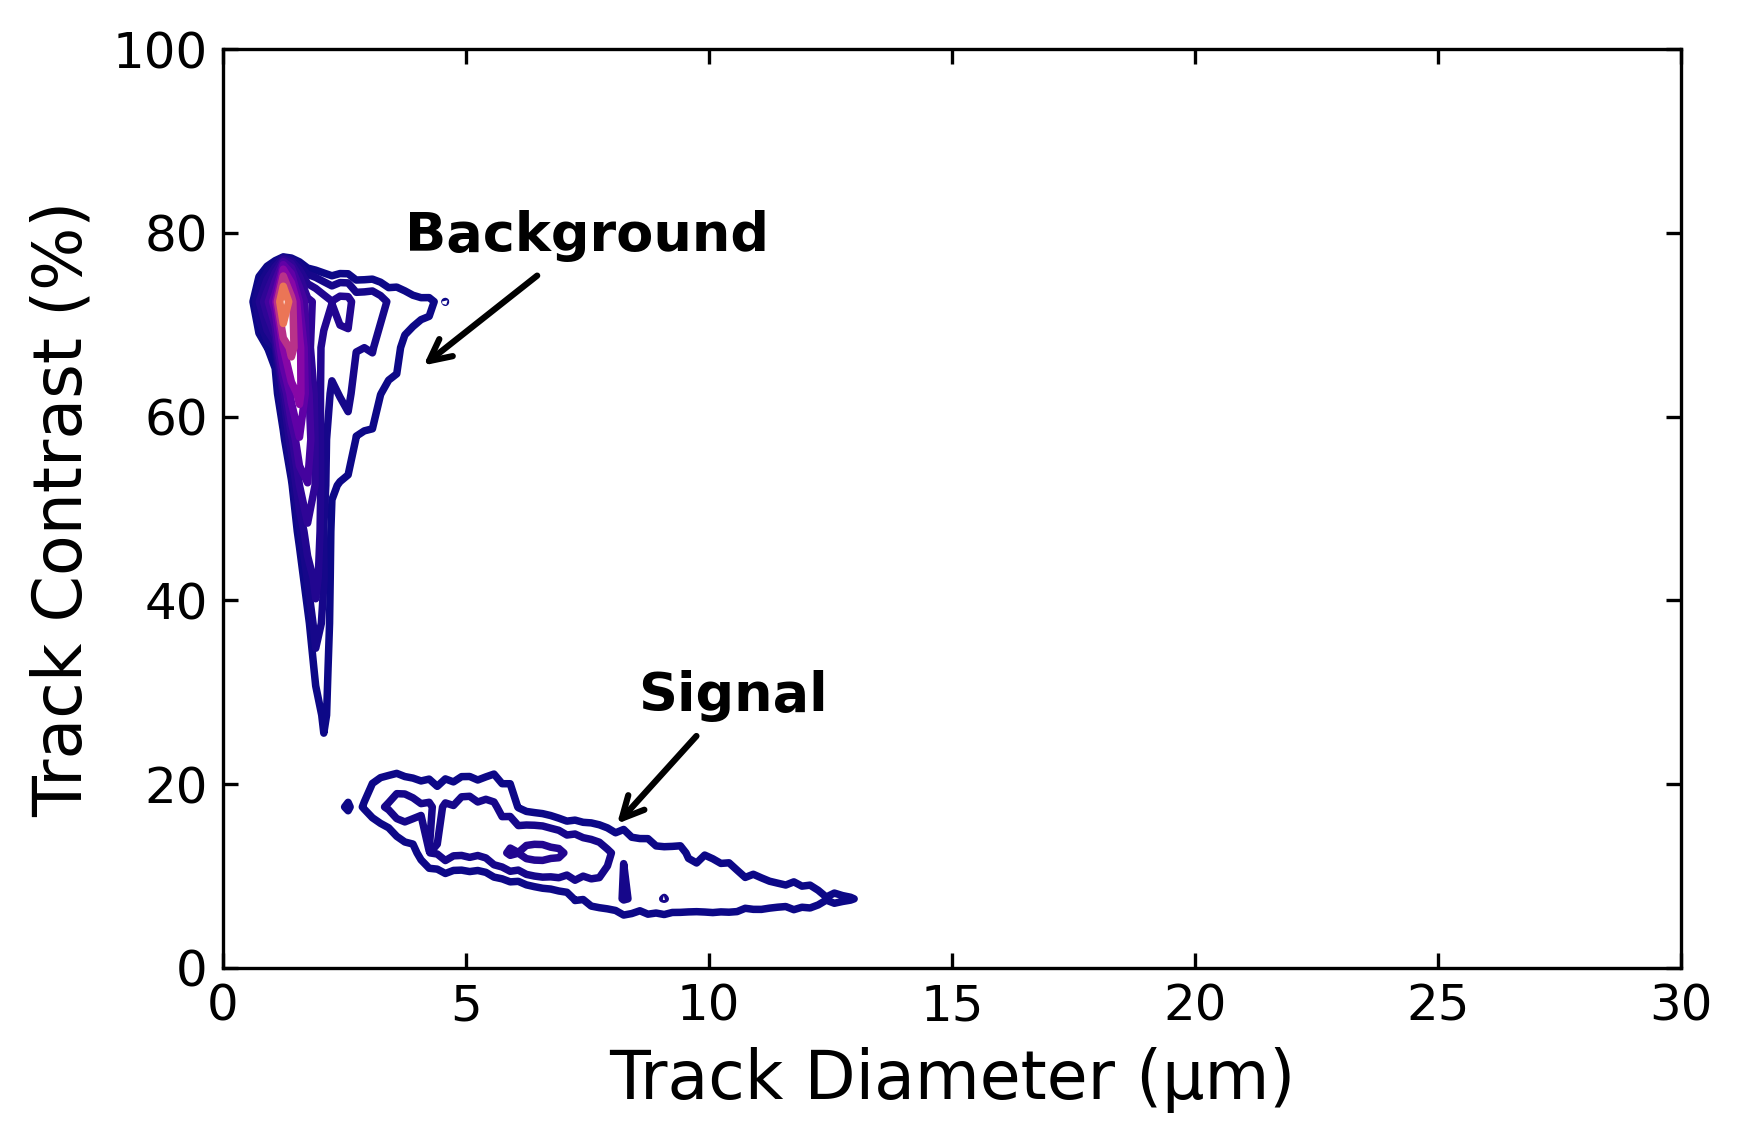

In [10]:
# ── Diameter vs. Normal-Contrast contour (raw, no quality cuts) ───────────────
# Use this plot to choose D_MIN/D_MAX and C_MAX in the config cell.

fig, ax = plt.subplots(figsize=(6,4),dpi=300)

H, xedges, yedges = np.histogram2d(tr['d'], tr['c'],
                                    bins=[150, 100],
                                    range=[[0, 25], [0, 500]])
xc = 0.5 * (xedges[:-1] + xedges[1:])
yc = 0.5 * (yedges[:-1] + yedges[1:])

MIN_COUNT = 800
if H.max() > MIN_COUNT:
    levels = np.logspace(np.log10(MIN_COUNT), np.log10(H.max()), 10)
    cs = ax.contour(xc, yc, H.T, levels=levels, cmap='plasma', linewidths=1.8)
    #fig.colorbar(cs, ax=ax, label='Counts per bin')

# Overlay the cut boundaries used in analysis
#ax.axvline(D_MIN, color='lime',  lw=1.5, ls='--', label=f'd_min = {D_MIN} µm')
#ax.axvline(D_MAX, color='cyan',  lw=1.5, ls='--', label=f'd_max = {D_MAX} µm')
#ax.axhline(C_MAX, color='red',   lw=1.5, ls='--', label=f'c_max = {C_MAX}')

ax.set_xlim(0, 30)
ax.set_ylim(0, 100)
ax.set_xlabel('Track Diameter (µm)',fontsize=16)
ax.set_ylabel('Track Contrast (%)',fontsize=16)
#ax.set_title('Raw: Diameter vs. Contrast  (cut lines shown)')
#ax.legend(fontsize=11, loc='upper right')
arrow_props = dict(arrowstyle='->', color='black', lw=1.5)
ax.annotate('Signal',
            xy=(8, 15),           # arrow tip  → tweak to your lower island peak
            xytext=(10.5, 28),    # label position
            fontsize=13, color='black', fontweight='bold',
            arrowprops=arrow_props,
            ha='center')

# Upper island → Background
ax.annotate('Background',
            xy=(4, 65),           # arrow tip  → tweak to your upper island peak
            xytext=(7.5, 78),     # label position
            fontsize=13, color='black', fontweight='bold',
            arrowprops=arrow_props,
            ha='center')
fig.tight_layout()
#fig.savefig(f'{PLOT_DIR}/00_precut_d_vs_contrast.png', dpi=300)
plt.show()

### C vs D by region — Signal box vs Background notch

Per-region Contrast-vs-Diameter heatmaps on **raw tracks (no quality cuts)**:
- **Background notch** (top of detector, sees no reaction protons): should contain
  only the noise island — small diameters (< 5 µm) at high contrast (> 40%).
- **Signal box** (centre): should contain that same noise island **plus** the
  low-contrast signal island of 5.6 MeV proton tracks (d ≈ 2–13 µm).

Comparing the two panels confirms that the quality cuts
d ∈ [2.0, 13.0] µm and c < 20 isolate the signal island and remove the noise
cluster before any background subtraction is done.


### What this next cell does, in plain English

**The problem.** Our plastic detector has real proton tracks on it, but it also
has junk: scratches, dust, cosmic-ray hits, and stray particles bouncing around
the chamber. We only want to count the real protons. So we need to figure out
how much junk there is, and take it away.

**The trick.** We look at two places on the same piece of plastic:

- The **signal box** (middle) — this is where the protons hit. It has protons **+ junk**.
- The **background notch** (top strip) — the protons shouldn't reach here. It has **junk only**.

If we measure the junk in the notch, we can subtract it from the middle and be
left with just the protons. But the notch is *smaller* than the box, so it
naturally has fewer tracks. We scale it up by how much bigger the box is
(`A_sig / A_bg` ≈ 8.67× bigger) before subtracting. Like comparing a small
scoop of soup to a big bowl — you have to account for the size difference.

**Why we plot "C vs D".** Every track has two measurable properties:

- **D = Diameter** — how wide the pit is (in µm, a millionth of a metre)
- **C = Contrast** — how dark it looks under the microscope (%)

Real protons and junk tend to sit in *different places* on a C-vs-D plot. Junk
is usually small and dark (small D, high C). Protons are usually wider and
lighter (D ≈ 2–13 µm, C < 20). So instead of just counting "how many tracks",
we make a 2D map of where they sit and subtract *map from map*. That way we
remove junk **where the junk actually is**, instead of assuming it's spread
evenly everywhere.

**The order matters (this is the meeting-3 fix).** We used to throw away tracks
outside our D/C window *first*, then subtract one number. That's backwards. Now we:

1. Keep almost everything (only drop very stretched tracks, `e ≤ 15`)
2. Make the C-vs-D map for the box, and for the notch
3. Scale the notch map up by 8.67×
4. Subtract map − map, square by square
5. **Then** keep only the squares inside the good window (D 2–13 µm, C < 20)
6. Add up what's left → that's our proton count

**Reading the three plots:** left = box (protons + junk), middle = notch scaled
up (junk only), right = what's left after subtracting (should be protons).
Red = leftover tracks, blue = we subtracted too much, white = nothing left.


In [ ]:
# ── C vs D heatmap background subtraction (signal / background / subtracted) ──
# MEETING-3 ORDERING FIX. Previous flow applied the full D+C+e cuts first and
# only then subtracted an area-scaled *scalar* track count. That misses
# background which clusters in a specific part of C-D space rather than being
# spread uniformly across it.
#
# Correct flow implemented here:
#   1. eccentricity cut ONLY (e <= E_MAX) — no diameter/contrast cut yet
#   2. build the C-vs-D 2D heatmap for the signal region
#   3. build the C-vs-D 2D heatmap for the background notch
#   4. scale the background heatmap by A_sig / A_bg
#   5. subtract it from the signal heatmap, bin by bin
#   6. apply the diameter + contrast cuts to the SUBTRACTED heatmap
#   7. sum the surviving bins -> net signal

# ── Step 1: eccentricity cut ONLY ────────────────────────────────────────────
# 'Eccentricity' = how stretched/oval a track is. A perfectly round pit has
# e = 0; a long smeared streak has a big e. Very stretched tracks are almost
# always scratches or scanner errors, never protons, so we drop them now.
# We do NOT touch diameter or contrast yet — that is the whole point of the
# reordering. We need the junk still present so we can measure and remove it.
tr_e = tr[(tr['e'] >= E_MIN) & (tr['e'] <= E_MAX)]
print(f'Raw tracks: {len(tr):,} → after eccentricity cut only (e ≤ {E_MAX}): {len(tr_e):,}')

# A 'mask' is just a yes/no list, one entry per track: is this track inside
# the box? Every track needs its x AND y to be inside the box's edges.
sig_region = (
    (tr_e['x'] >= SIG_XMIN) & (tr_e['x'] <= SIG_XMAX) &
    (tr_e['y'] >= SIG_YMIN) & (tr_e['y'] <= SIG_YMAX)
)
bg_region = (
    (tr_e['x'] >= BG_XMIN) & (tr_e['x'] <= BG_XMAX) &
    (tr_e['y'] >= BG_YMIN) & (tr_e['y'] <= BG_YMAX)
)
tr_sig, tr_bg = tr_e[sig_region], tr_e[bg_region]

# ── Steps 2-3: C-vs-D heatmaps. Bin edges are chosen so the cut boundaries
# (D_MIN=2.0, D_MAX=13.0, C_MAX=20) land exactly on bin edges — otherwise the
# cut in step 6 would slice through a bin and mis-count it.
D_EDGES = np.arange(0.0, 25.0 + 0.2, 0.2)     # 0.2 µm bins  → 2.0 and 13.0 are edges
C_EDGES = np.arange(0.0, 100.0 + 1.0, 1.0)    # 1.0 unit bins → 20 is an edge

# histogram2d = 'sort every track into a pigeonhole grid'. Picture graph paper
# laid over the C-vs-D plot: each little square counts how many tracks had
# that diameter AND that contrast. H_sig is the grid for the box, H_bg for
# the notch. Both grids use the SAME squares, which is what lets us subtract
# one from the other square-by-square further down.
H_sig, _, _ = np.histogram2d(tr_sig['d'], tr_sig['c'], bins=[D_EDGES, C_EDGES])
H_bg,  _, _ = np.histogram2d(tr_bg['d'],  tr_bg['c'],  bins=[D_EDGES, C_EDGES])

# ── Step 4: area-scale the background heatmap ────────────────────────────────
A_sig_cvd = (SIG_XMAX - SIG_XMIN) * (SIG_YMAX - SIG_YMIN)   # cm²
A_bg_cvd  = (BG_XMAX  - BG_XMIN)  * (BG_YMAX  - BG_YMIN)    # cm²
# The box is ~8.67x bigger than the notch, so of course it collects ~8.67x
# more junk. Multiply the notch's junk up to 'box size' before subtracting,
# or we would only remove a small fraction of the junk that is really there.
scale_cvd = A_sig_cvd / A_bg_cvd
H_bg_scaled = H_bg * scale_cvd

# ── Step 5: bin-by-bin subtraction ──────────────────────────────────────────
# The actual subtraction, and it is this simple: for every square on the
# graph paper, (what the box had) minus (what the junk should be).
# Whatever survives should be protons and protons only.
# Some squares go slightly negative — that is normal random wobble, not a
# bug. Counting is noisy, so sometimes we subtract a hair too much.
H_sub = H_sig - H_bg_scaled

# ── Step 6: apply diameter + contrast cuts to the SUBTRACTED heatmap ────────
d_ctr = 0.5 * (D_EDGES[:-1] + D_EDGES[1:])
c_ctr = 0.5 * (C_EDGES[:-1] + C_EDGES[1:])
DD, CC = np.meshgrid(d_ctr, c_ctr, indexing='ij')
cut_box = (DD >= D_MIN) & (DD <= D_MAX) & (CC >= C_MIN) & (CC <= C_MAX)

# ── Step 7: sum surviving bins ──────────────────────────────────────────────
# Add up every square inside the good window. This is our proton count:
# junk removed FIRST, quality window applied SECOND.
N_signal_net_cvd = H_sub[cut_box].sum()

# ── Plot: signal / scaled background / subtracted ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4.6), dpi=300, sharex=True, sharey=True)
extent = [D_EDGES[0], D_EDGES[-1], C_EDGES[0], C_EDGES[-1]]

for ax, H, title, is_diff in [
    (axes[0], H_sig,       f'Signal region (e-cut only)\nN = {H_sig.sum():,.0f}', False),
    (axes[1], H_bg_scaled, f'Background × {scale_cvd:.2f}\nN = {H_bg_scaled.sum():,.0f}', False),
    (axes[2], H_sub,       f'Subtracted (signal − background)\nN = {H_sub.sum():,.0f}', True),
]:
    if is_diff:
        # Diverging map centred at 0: the subtracted panel legitimately goes
        # negative where the background over-subtracts within statistics.
        lim = np.abs(H).max()
        im = ax.imshow(H.T, origin='lower', extent=extent, aspect='auto',
                       cmap='RdBu_r', norm=SymLogNorm(linthresh=1.0, vmin=-lim, vmax=lim))
        cbar_label = 'Net counts'
    else:
        im = ax.imshow(H.T, origin='lower', extent=extent, aspect='auto',
                       cmap='inferno', norm=LogNorm(vmin=1))
        cbar_label = 'Counts'
    fig.colorbar(im, ax=ax, pad=0.02, label=cbar_label)

    ax.axvline(D_MIN, color='cyan', lw=1.5, ls='--', label=f'd ∈ [{D_MIN}, {D_MAX}] µm')
    ax.axvline(D_MAX, color='cyan', lw=1.5, ls='--')
    ax.axhline(C_MAX, color='lime', lw=1.5, ls='--', label=f'c ≤ {C_MAX}')
    ax.set_xlabel('Track Diameter (µm)')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8, loc='upper right')

axes[0].set_ylabel('Track Contrast (%)')
fig.tight_layout()
fig.savefig(f'{PLOT_DIR}/precut_cvsd_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Report ──────────────────────────────────────────────────────────────────
n_sig_in_cut = H_sig[cut_box].sum()
n_bg_in_cut  = H_bg_scaled[cut_box].sum()
print()
print('=' * 66)
print('  C vs D HEATMAP SUBTRACTION (subtract first, then cut)')
print('=' * 66)
print(f'Area scale factor A_sig/A_bg          : {scale_cvd:.4f}')
print(f'Signal heatmap, inside D+C cut box    : {n_sig_in_cut:>12,.1f}')
print(f'Background heatmap (scaled), in box   : {n_bg_in_cut:>12,.1f}')
print(f'Net signal (subtract → then cut)      : {N_signal_net_cvd:>12,.1f}')
print('=' * 66)


### Diagnostic — is the background notch actually free of protons?

The subtracted plot above did **not** come out how we hoped. We expected the junk
to vanish and a clean island of protons to remain. Instead almost everything
cancelled: the notch, scaled up, accounted for ~92% of what was in the signal box.

There are only two ways that happens:

1. **The notch has protons in it too.** If protons are landing on the notch, then
   subtracting the notch subtracts *real signal* along with the junk — we'd be
   erasing our own data. The notch would be the wrong place to measure junk.
2. **The plastic is genuinely that noisy.** The junk really is ~92% of everything,
   and the real proton signal is a small bump sitting on a mountain of noise.

These need different fixes, so we have to tell them apart. The test below is
simple: **walk up the detector from bottom to top and count tracks at each height.**

- If protons only hit the middle, the count should be **high in the box and then
  drop off to a low flat floor** by the time we reach the notch. Flat floor = clean
  notch = case 2.
- If the count is **still sloping downward at the notch**, we're standing on the
  edge of the proton spot, not off it. The notch is contaminated = case 1.


In [ ]:
# ── DIAGNOSTIC: walk up the detector and count tracks at each height ─────────
# GOAL: find out whether the background notch is really outside the proton spot.
#
# HOW: slice the detector into thin horizontal strips (like slicing a loaf of
# bread), count the tracks in each slice, and divide by the slice's area to get
# a DENSITY (tracks per cm²). Density, not raw counts, because slices could have
# different widths — density makes them fair to compare.
#
# WHAT TO LOOK FOR: a flat floor under the notch means the notch is clean.
# A slope still falling at the notch means protons are leaking into it.

# Use the same eccentricity-cut tracks as the subtraction above, and restrict to
# the same x-width as the signal box, so we are comparing like with like.
in_x = (tr_e['x'] >= SIG_XMIN) & (tr_e['x'] <= SIG_XMAX)
y_vals = tr_e['y'][in_x]

# Slice from the bottom of the detector to the top in 0.1 cm steps.
y_edges = np.arange(-2.5, 2.5 + 0.1, 0.1)
counts_per_slice, _ = np.histogram(y_vals, bins=y_edges)

# The CR-39 piece is a CIRCLE (radius ~2.5 cm), not a square. Near the top and
# bottom the circle curves inward, so a slice there contains LESS plastic than a
# slice through the middle. If we divided every slice by the same area we would
# see a fake "falloff" at the edges that is just the piece running out — not the
# signal dying. So for each slice we work out how much plastic is actually in it.
y_mid = 0.5 * (y_edges[:-1] + y_edges[1:])       # the height of each slice
R_PIECE = 2.5                                    # cm, radius of the CR-39 piece

# Half-width of the circle at each height (0 once we are past the top/bottom).
half_w = np.sqrt(np.clip(R_PIECE**2 - y_mid**2, 0, None))
# The slice only counts where the circle AND our x-window overlap.
x_lo = np.maximum(SIG_XMIN, -half_w)
x_hi = np.minimum(SIG_XMAX,  half_w)
on_piece_width = np.clip(x_hi - x_lo, 0, None)
slice_area = on_piece_width * (y_edges[1] - y_edges[0])

# Ignore slices with almost no plastic — dividing by ~0 explodes the density.
valid = slice_area > 1e-3
density = np.full_like(y_mid, np.nan, dtype=float)
density[valid] = counts_per_slice[valid] / slice_area[valid]

# Poisson error bars: counting N things has an uncertainty of about sqrt(N).
density_err = np.full_like(y_mid, np.nan, dtype=float)
density_err[valid] = np.sqrt(counts_per_slice[valid]) / slice_area[valid]

fig, ax = plt.subplots(figsize=(11, 5), dpi=300)
ax.errorbar(y_mid, density, yerr=density_err, fmt='o-', ms=3, lw=1,
            color='black', ecolor='gray', label='Track density (e-cut only)')

# Shade where the signal box is (green) and where the notch is (blue).
ax.axvspan(SIG_YMIN, SIG_YMAX, color='green', alpha=0.12, label='Signal box')
ax.axvspan(BG_YMIN,  BG_YMAX,  color='blue',  alpha=0.15, label='Background notch')

ax.set_xlabel('y position on detector (cm)   —   bottom → top')
ax.set_ylabel('Track density (tracks / cm²)')
ax.set_title('Does the proton signal die out before the notch?', fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(f'{PLOT_DIR}/y_profile_notch_check.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Put numbers on it instead of eyeballing the plot ────────────────────────
# Compare the density inside the notch against the density in the signal box.
# If the notch were clean junk-only plastic, its density should be MUCH lower.
in_box   = (y_mid >= SIG_YMIN) & (y_mid <= SIG_YMAX)
in_notch = (y_mid >= BG_YMIN)  & (y_mid <= BG_YMAX)

box_density   = np.nanmean(density[in_box])
notch_density = np.nanmean(density[in_notch])

# Also check the very top edge of the detector — the furthest we can possibly get
# from the proton spot. If even the notch is contaminated, the top edge is the
# closest thing we have to "true" junk-only plastic.
top_edge = (y_mid > BG_YMAX) & valid
top_density = np.nanmean(density[top_edge]) if top_edge.sum() > 0 else float('nan')

print('=' * 66)
print('  IS THE NOTCH CLEAN?')
print('=' * 66)
print(f'Average density inside signal box   : {box_density:>10,.0f} tracks/cm²')
print(f'Average density inside notch        : {notch_density:>10,.0f} tracks/cm²')
print(f'Average density above the notch     : {top_density:>10,.0f} tracks/cm²')
print('-' * 66)
print(f'Notch / box ratio                   : {notch_density/box_density:>10.3f}')
print(f'   (≈ 0 would mean a clean notch; ≈ 1 means the notch looks')
print(f'    just like the signal box, i.e. protons are landing on it)')
print()
print('WHAT THIS MEANS: the notch is ~90% as dense as the signal box, and the')
print('profile is flat right across the piece. The notch is NOT a shadowed,')
print('signal-free reference region — it looks like the same illuminated field')
print('as the signal box. Subtracting it removes ~90% of whatever is there.')
print()
print('CAVEAT: the "above the notch" number sits near the curved edge of the')
print('piece, where fewer frames were scanned and the area correction is least')
print('reliable — do not read the edge falloff as a physical signal falloff.')
print('=' * 66)


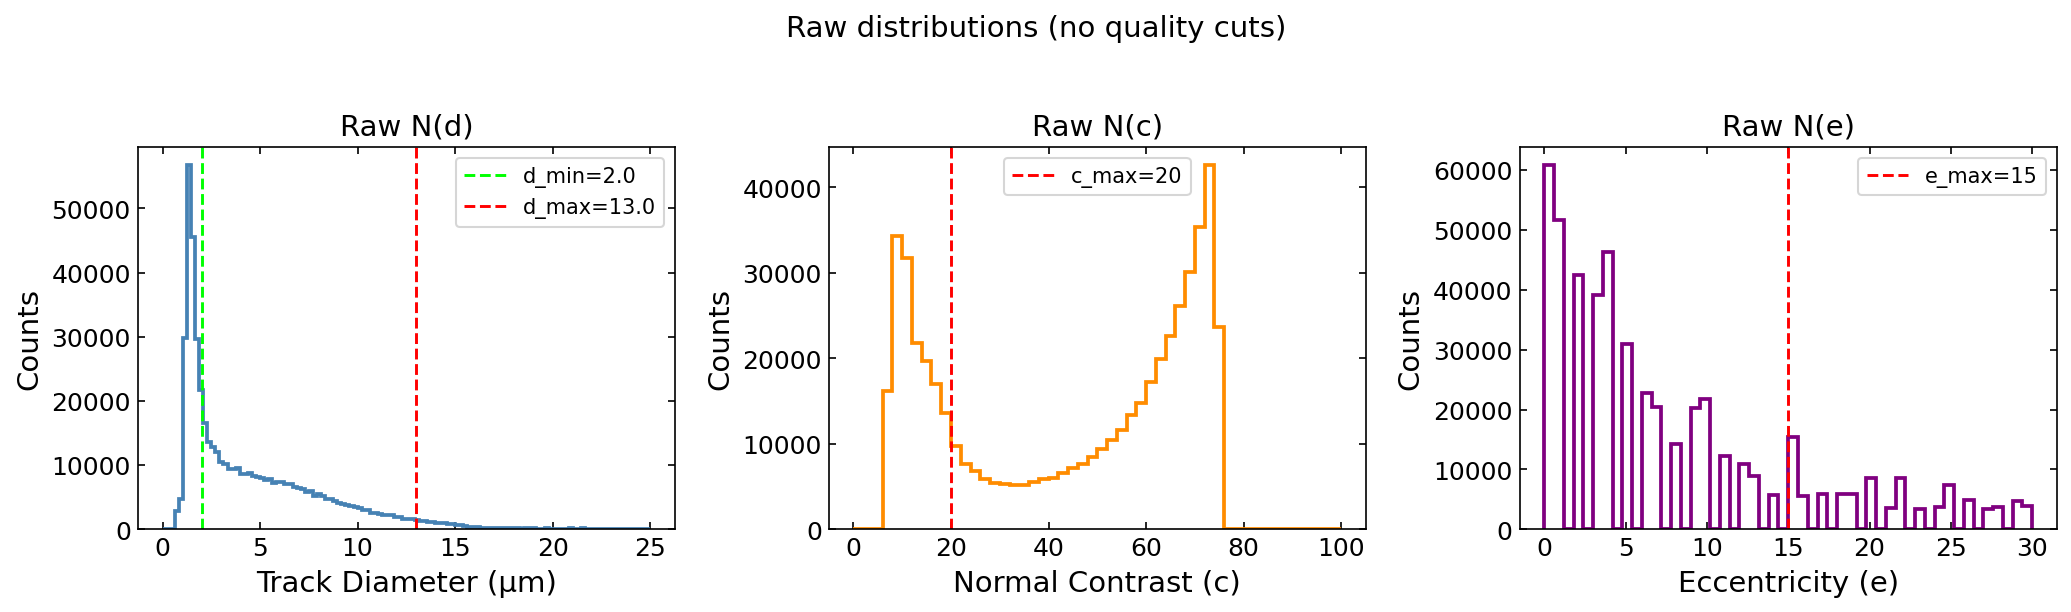

In [11]:
# ── Raw 1D distributions of d, c, and e ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(tr['d'], bins=120, range=(0, 25), histtype='step', lw=1.8, color='steelblue')
axes[0].axvline(D_MIN, color='lime', ls='--', lw=1.4, label=f'd_min={D_MIN}')
axes[0].axvline(D_MAX, color='red',  ls='--', lw=1.4, label=f'd_max={D_MAX}')
axes[0].set_xlabel('Track Diameter (µm)')
axes[0].set_ylabel('Counts')
axes[0].set_title('Raw N(d)')
axes[0].legend(fontsize=10)

axes[1].hist(tr['c'], bins=BINS_C, range=(0, 100), histtype='step', lw=1.8, color='darkorange')
axes[1].axvline(C_MAX, color='red', ls='--', lw=1.4, label=f'c_max={C_MAX}')
axes[1].set_xlabel('Normal Contrast (c)')
axes[1].set_ylabel('Counts')
axes[1].set_title('Raw N(c)')
axes[1].legend(fontsize=10)

axes[2].hist(tr['e'], bins=50, range=(0, 30), histtype='step', lw=1.8, color='purple')
axes[2].axvline(E_MAX, color='red', ls='--', lw=1.4, label=f'e_max={E_MAX}')
axes[2].set_xlabel('Eccentricity (e)')
axes[2].set_ylabel('Counts')
axes[2].set_title('Raw N(e)')
axes[2].legend(fontsize=10)

fig.suptitle('Raw distributions (no quality cuts)', y=1.02, fontsize=14)
fig.tight_layout()
#fig.savefig(f'{PLOT_DIR}/01_precut_1D_distributions.png', dpi=300)
plt.show()


C:\Users\sayak\AppData\Local\Temp\ipykernel_6436\3860695603.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10)


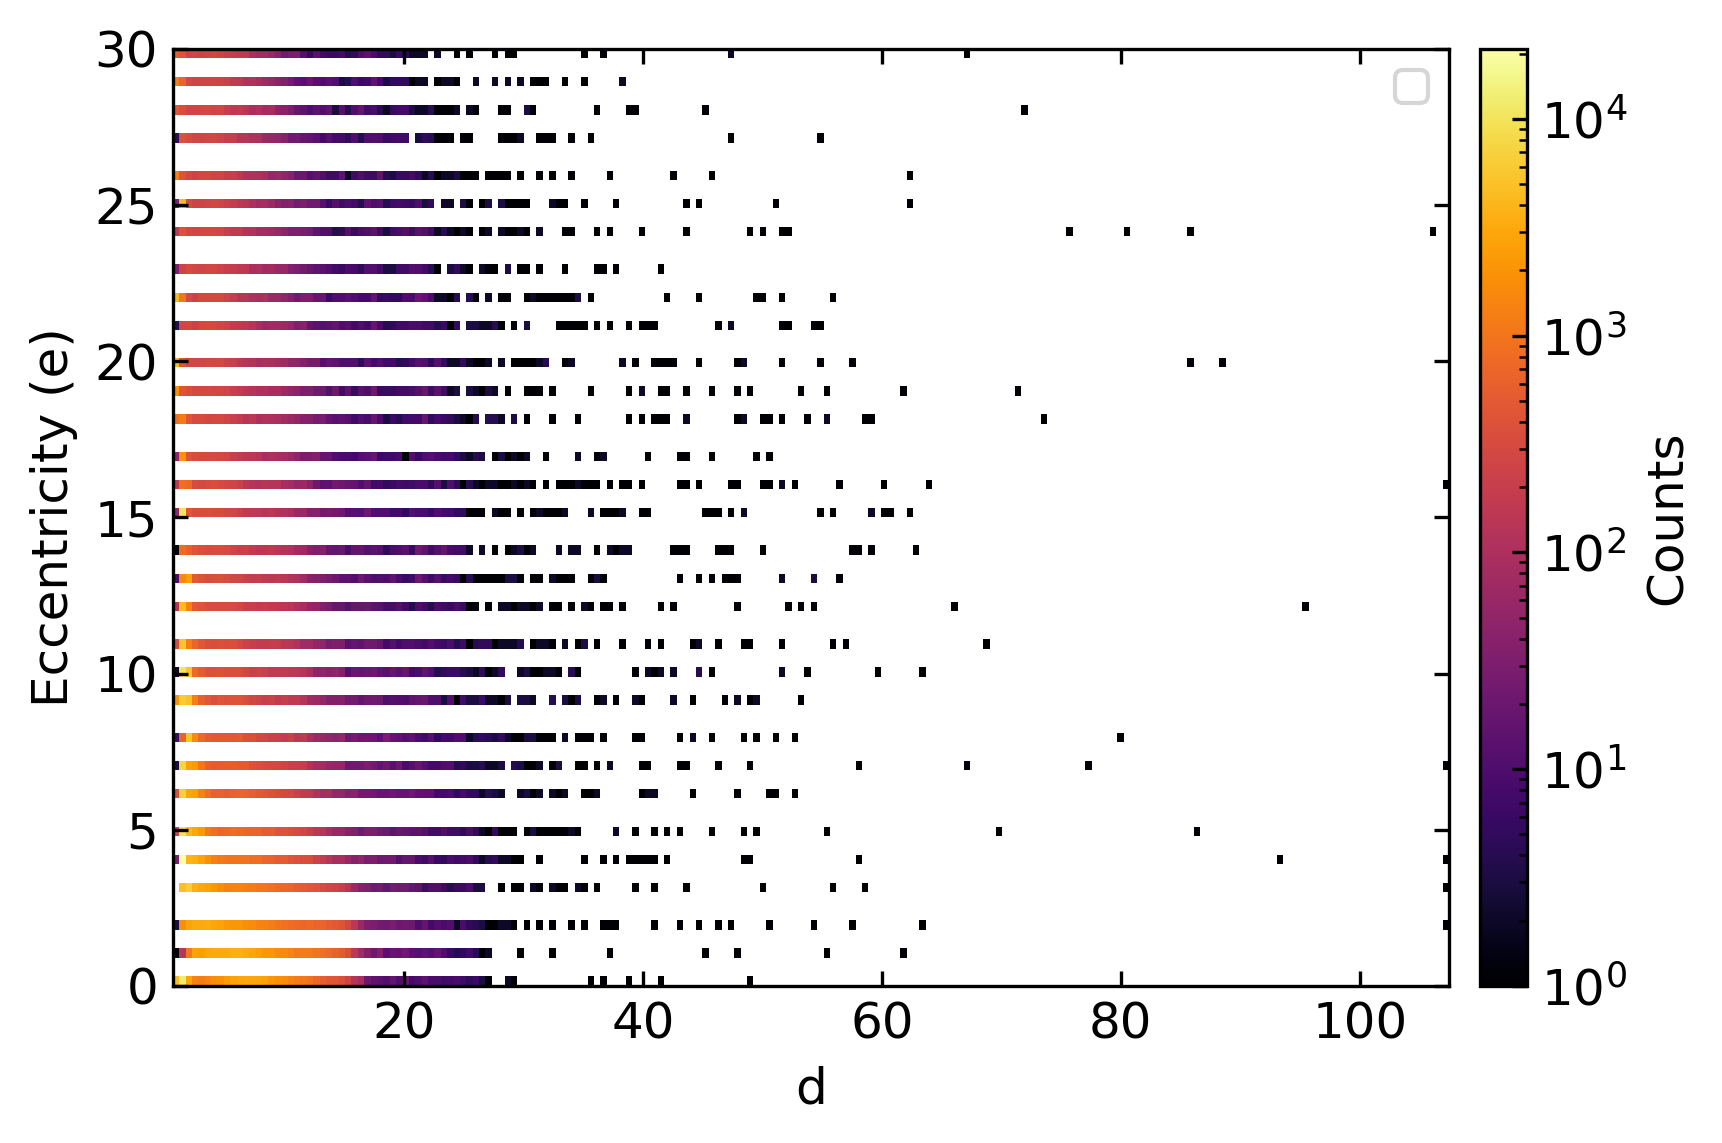

In [12]:
import matplotlib.colors as mcolors

# ── 2D Heatmap: Eccentricity vs X (counts on z-axis) ─────────────────────────
fig, ax = plt.subplots(figsize=(6, 4),dpi=300)

h, xedges, yedges, img = ax.hist2d(
    tr['d'], tr['e'],
    bins=[200, 100],
    range=[[tr['d'].min(), tr['d'].max()], [0, 30]],
    cmap='inferno',
    norm=mcolors.LogNorm(vmin=1)
)

cbar = fig.colorbar(img, ax=ax, pad=0.02)
cbar.set_label('Counts', fontsize=12)

# Optional: overlay the E_MAX cut line
#ax.axhline(E_MAX, color='cyan', ls='--', lw=1.4, label=f'e_max = {E_MAX}')
ax.legend(fontsize=10)

ax.set_xlabel('d', fontsize=12)
ax.set_ylabel('Eccentricity (e)', fontsize=12)
#ax.set_title('Heatmap: Eccentricity vs X  [raw counts]', fontsize=14)

fig.tight_layout()
#plt.yscale("log")
#fig.savefig(f'{PLOT_DIR}/heatmap_eccentricity_vs_x.png', dpi=300)
plt.show()

## 6. Track Density Map with Projections

2D spatial histogram of all tracks passing the quality cuts,  
with marginal x (top) and y (right) projections.

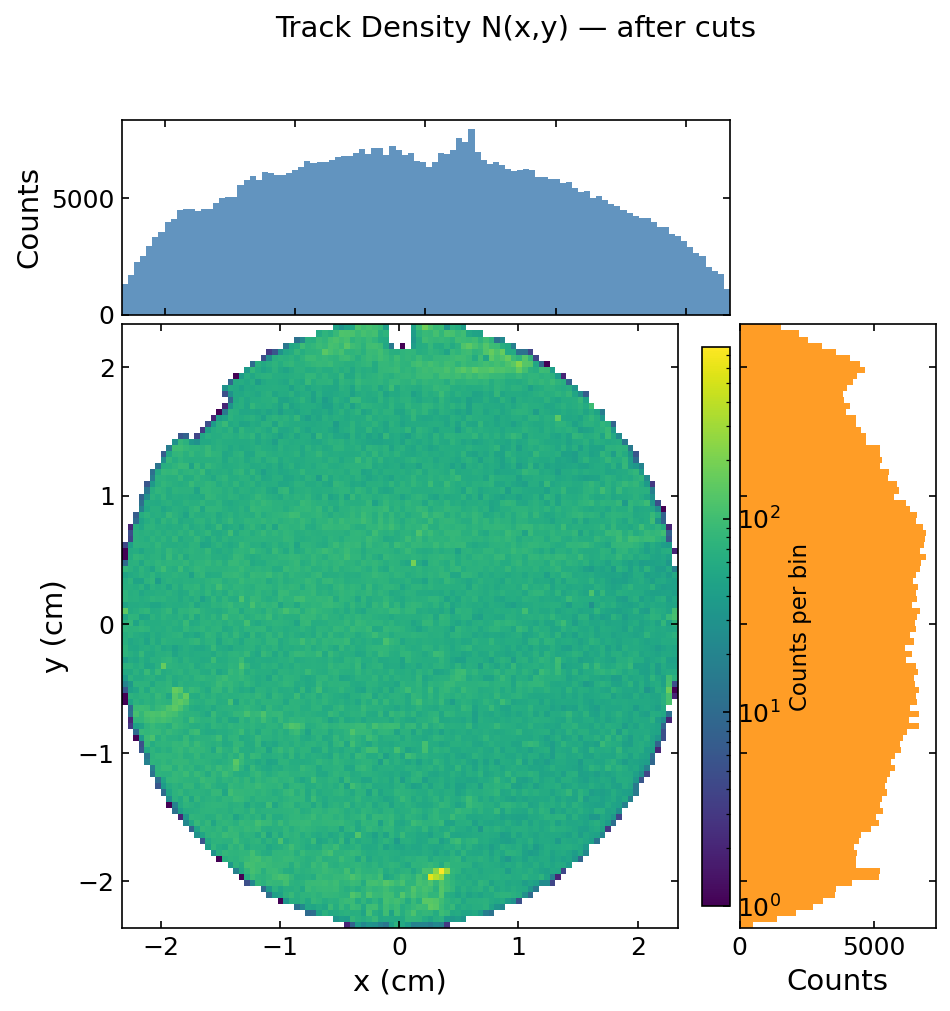

In [13]:
x = tr['x']
y = tr['y']

# ── Layout: 4×4 GridSpec — main 2D plot + two marginal projections ─────────
fig = plt.figure(figsize=(7, 7))
gs  = GridSpec(4, 4, figure=fig, hspace=0.05, wspace=0.05)

ax_main  = fig.add_subplot(gs[1:4, 0:3])
ax_xproj = fig.add_subplot(gs[0,   0:3], sharex=ax_main)
ax_yproj = fig.add_subplot(gs[1:4, 3],   sharey=ax_main)

# ── Main 2D histogram (log colour scale) ─────────────────────────────────────
h2d = ax_main.hist2d(x, y, bins=BINS_XY, norm=LogNorm(), cmap='viridis')
cbar = fig.colorbar(h2d[3], ax=ax_main, fraction=0.046, pad=0.04)
cbar.set_label('Counts per bin', fontsize=11)

ax_main.set_xlabel('x (cm)')
ax_main.set_ylabel('y (cm)')
ax_main.tick_params(which='both', direction='in', top=True, right=True)

# ── X projection (top panel) ─────────────────────────────────────────────────
cx, bx = np.histogram(x, bins=BINS_XY)
bxc    = 0.5 * (bx[:-1] + bx[1:])
ax_xproj.bar(bxc, cx, width=bx[1]-bx[0], color='steelblue', alpha=0.85)
ax_xproj.set_ylabel('Counts')
ax_xproj.tick_params(direction='in', labelbottom=False)

# ── Y projection (right panel) ────────────────────────────────────────────────
cy, by = np.histogram(y, bins=BINS_XY)
byc    = 0.5 * (by[:-1] + by[1:])
ax_yproj.barh(byc, cy, height=by[1]-by[0], color='darkorange', alpha=0.85)
ax_yproj.set_xlabel('Counts')
ax_yproj.tick_params(direction='in', labelleft=False)

fig.suptitle('Track Density N(x,y) — after cuts', y=0.98, fontsize=14)
#fig.savefig(f'{PLOT_DIR}/02_track_density_with_projections.png', dpi=300,bbox_inches='tight')
plt.show()

## 7. Track Density Map with Projections with cuts 

2D spatial histogram of all tracks with the quality cuts,  
with marginal x (top) and y (right) projections.

Reading frames: 100%|████████████████████████████████| 15264/15264 [00:00<00:00, 29942.12fr/s]


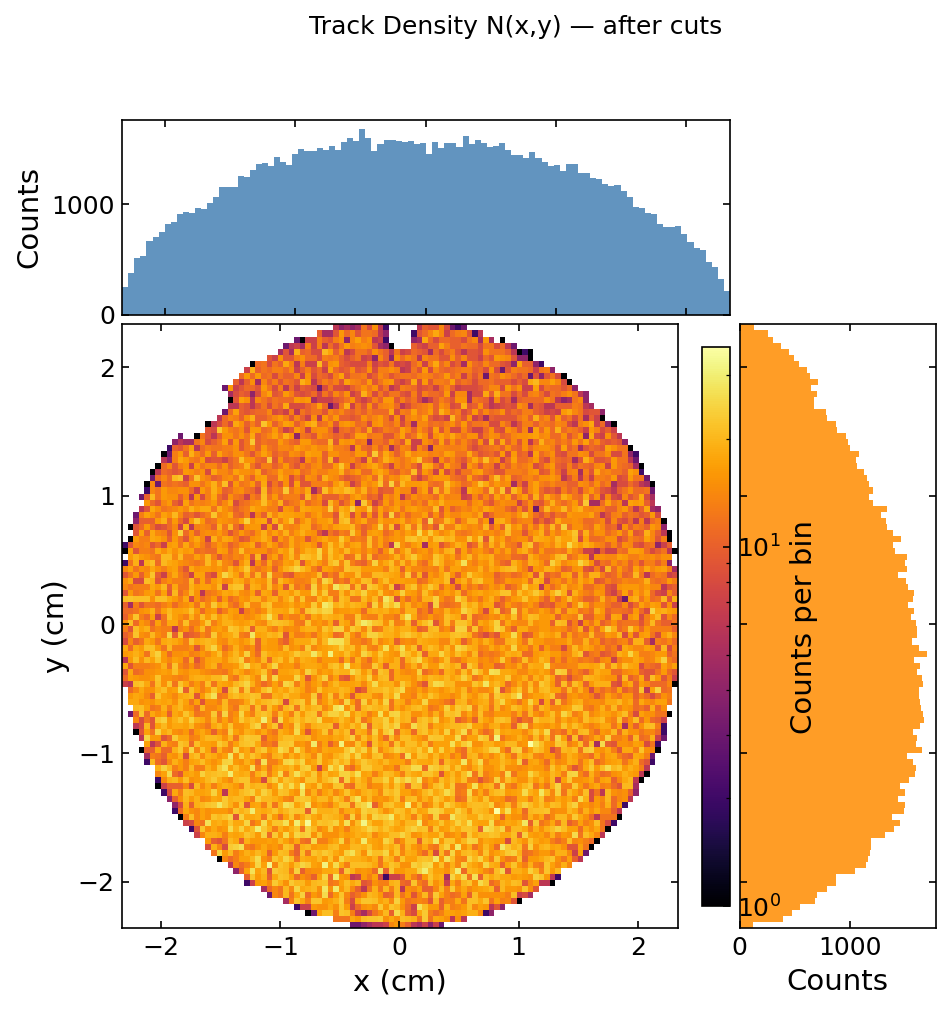

In [14]:
# Re-load with the latest cuts (in case you tweaked them above) and re-plot.
data  = ScanData(
    CPSA_FILE,
    d_bounds=(D_MIN, D_MAX),
    e_bounds=(E_MIN, E_MAX),
    c_bounds=(C_MIN, C_MAX),
    x_bounds=(X_MIN, X_MAX),
    y_bounds=(Y_MIN, Y_MAX),
)
tracks = data.tracks
x_cut, y_cut = tracks['x'], tracks['y']

fig = plt.figure(figsize=(7, 7), dpi=150)
gs  = GridSpec(4, 4, figure=fig, hspace=0.05, wspace=0.05)
ax_main  = fig.add_subplot(gs[1:4, 0:3])
ax_xproj = fig.add_subplot(gs[0,   0:3], sharex=ax_main)
ax_yproj = fig.add_subplot(gs[1:4, 3],   sharey=ax_main)

h2d = ax_main.hist2d(x_cut, y_cut, bins=BINS_XY, norm=LogNorm(), cmap='inferno')
fig.colorbar(h2d[3], ax=ax_main, fraction=0.046, pad=0.04, label='Counts per bin')
ax_main.set_xlabel('x (cm)'); ax_main.set_ylabel('y (cm)')

cx, bx = np.histogram(x_cut, bins=BINS_XY)
bxc    = 0.5 * (bx[:-1] + bx[1:])
ax_xproj.bar(bxc, cx, width=bx[1]-bx[0], color='steelblue', alpha=0.85)
ax_xproj.set_ylabel('Counts'); ax_xproj.tick_params(direction='in', labelbottom=False)

cy, by = np.histogram(y_cut, bins=BINS_XY)
byc    = 0.5 * (by[:-1] + by[1:])
ax_yproj.barh(byc, cy, height=by[1]-by[0], color='darkorange', alpha=0.85)
ax_yproj.set_xlabel('Counts'); ax_yproj.tick_params(direction='in', labelleft=False)

fig.suptitle(f'Track Density N(x,y) — after cuts', y=0.98, fontsize=12)
#fig.savefig(PLOT_DIR / '02b_track_density_after_cuts.png', dpi=300, bbox_inches='tight')
plt.show()


## 7. Signal & Background Region Analysis

- **Signal region** (red rectangle): the area containing the reaction products.
- **Background strip** (blue rectangle): a same-width strip above the signal region,  
  used to estimate the uniform background track density.
- Background is **area-scaled** to the signal region and subtracted.

In [ ]:
#── Signal region (rectangular, drawn in red) ─────────────────────────────
SIG_XMIN, SIG_XMAX = -1.5,  1.5
SIG_YMIN, SIG_YMAX = -1.8,  1.4

# ── Background strip (same x width, above signal region, drawn in blue) ────────
BG_XMIN,  BG_XMAX  = -1.37,  1.47
BG_YMIN,  BG_YMAX  =  1.50,  1.89

# ── Boolean masks for signal and background regions ───────────────────────
sig_mask = (
    (x_cut >= SIG_XMIN) & (x_cut <= SIG_XMAX) &
    (y_cut >= SIG_YMIN) & (y_cut <= SIG_YMAX)
)
bg_mask = (
    (x_cut >= BG_XMIN) & (x_cut <= BG_XMAX) &
    (y_cut >= BG_YMIN) & (y_cut <= BG_YMAX)
)

N_sig_total = sig_mask.sum()   # total tracks inside signal rectangle
N_bg_strip  = bg_mask.sum()    # tracks in background strip

# Region areas
A_sig = (SIG_XMAX - SIG_XMIN) * (SIG_YMAX - SIG_YMIN)   # cm²
A_bg  = (BG_XMAX  - BG_XMIN)  * (BG_YMAX  - BG_YMIN)    # cm²
scale = A_sig / A_bg

# ── Background 1: spatial background (chamber-scattered particles) ──────────
# Estimated from the "empty" notch region at the top of the detector and
# area-scaled to the signal box.
N_bg_scaled = N_bg_strip * scale

# ── NO separate intrinsic-background term (meeting 3) ───────────────────
# The notch strip sits on the SAME physical piece of Chiyoda plastic as the
# signal box, so its measured density ALREADY contains the plastic's intrinsic
# ~100 tracks/cm² baseline. Subtracting the scaled notch and then subtracting
# 100 tracks/cm² again would double-count the intrinsic background.
# The spatial subtraction alone therefore removes both contributions.

# ── Net signal: spatial (notch) subtraction only ─────────────────────────
N_signal_net = N_sig_total - N_bg_scaled

print(f'Signal region   : x ∈ [{SIG_XMIN}, {SIG_XMAX}]  y ∈ [{SIG_YMIN}, {SIG_YMAX}]  → A = {A_sig:.4f} cm²')
print(f'Background strip: x ∈ [{BG_XMIN}, {BG_XMAX}]  y ∈ [{BG_YMIN}, {BG_YMAX}]  → A = {A_bg:.4f} cm²')
print(f'Area scale factor = A_sig / A_bg = {scale:.4f}')
print()
print(f'Tracks in signal box  (raw)         : {N_sig_total:>10,}')
print(f'Tracks in background strip          : {N_bg_strip:>10,}')
print(f'Background, scaled to signal box    : {N_bg_scaled:>10.1f}')
print(f'Net signal (spatial subtraction)    : {N_signal_net:>10.1f}')

# Statistical (Poisson) uncertainty on the net count.
sigma_net = np.sqrt(N_sig_total + scale**2 * N_bg_strip)
print(f'Statistical uncertainty (±1σ)       : ± {sigma_net:.1f}')


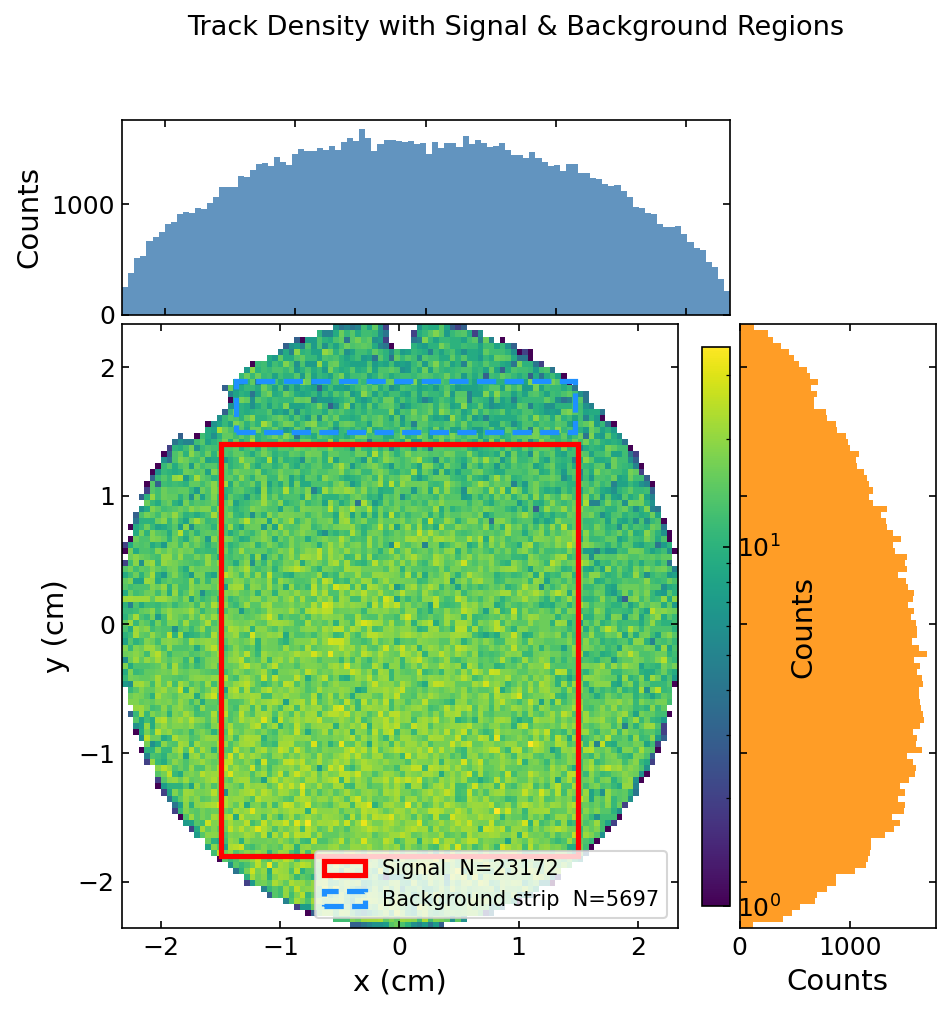

In [16]:
# ── Track density map with signal & background boxes overlaid ─────────────────
# This cell plots the 2D spatial track density after cuts and overlays
# the rectangular Signal region (red solid box) and the Background strip (blue dashed box)
# to visually verify the locations for count subtraction.
fig = plt.figure(figsize=(7, 7))
gs  = GridSpec(4, 4, figure=fig, hspace=0.05, wspace=0.05)

ax_main  = fig.add_subplot(gs[1:4, 0:3])
ax_xproj = fig.add_subplot(gs[0,   0:3], sharex=ax_main)
ax_yproj = fig.add_subplot(gs[1:4, 3],   sharey=ax_main)

# 2D histogram
h2d = ax_main.hist2d(x_cut, y_cut, bins=BINS_XY, norm=LogNorm(), cmap='viridis')
fig.colorbar(h2d[3], ax=ax_main, fraction=0.046, pad=0.04, label='Counts')

# Signal rectangle (red)
ax_main.add_patch(patches.Rectangle(
    (SIG_XMIN, SIG_YMIN),
    SIG_XMAX - SIG_XMIN, SIG_YMAX - SIG_YMIN,
    lw=2.5, edgecolor='red', facecolor='none',
    label=f'Signal  N={N_signal_net:.0f}'
))

# Background rectangle (blue)
ax_main.add_patch(patches.Rectangle(
    (BG_XMIN, BG_YMIN),
    BG_XMAX - BG_XMIN, BG_YMAX - BG_YMIN,
    lw=2.5, edgecolor='dodgerblue', facecolor='none', ls='--',
    label=f'Background strip  N={N_bg_strip}'
))

ax_main.set_xlabel('x (cm)')
ax_main.set_ylabel('y (cm)')
ax_main.legend(fontsize=10, loc='lower right')

# Projections
ax_xproj.bar(bxc, cx, width=bx[1]-bx[0], color='steelblue', alpha=0.85)
ax_xproj.set_ylabel('Counts')
ax_xproj.tick_params(direction='in', labelbottom=False)

ax_yproj.barh(byc, cy, height=by[1]-by[0], color='darkorange', alpha=0.85)
ax_yproj.set_xlabel('Counts')
ax_yproj.tick_params(direction='in', labelleft=False)

fig.suptitle('Track Density with Signal & Background Regions', y=0.98, fontsize=13)
#fig.savefig(f'{PLOT_DIR}/03_signal_background_regions.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# ── Refined Pixel-by-Pixel Background Subtraction (matching MIT Software) ────
# This cell performs the pixel-by-pixel background subtraction mimicking the MIT software.
# It calculates the physical background track density in the background strip (tracks/cm²),
# converts it to an average background count per pixel using the pixel area (A_pixel),
# and subtracts this value from each individual pixel in the signal region.
counts2d = h2d[0].T
xedges = h2d[1]
yedges = h2d[2]
xc = 0.5 * (xedges[:-1] + xedges[1:])
yc = 0.5 * (yedges[:-1] + yedges[1:])
XX, YY = np.meshgrid(xc, yc)

# Create mask for signal region pixels and background strip pixels
sig_pixel_mask = (XX >= SIG_XMIN) & (XX <= SIG_XMAX) & (YY >= SIG_YMIN) & (YY <= SIG_YMAX)
bg_pixel_mask = (XX >= BG_XMIN) & (XX <= BG_XMAX) & (YY >= BG_YMIN) & (YY <= BG_YMAX)

# Get pixel counts
raw_sig_pixels = counts2d[sig_pixel_mask]
bg_pixels = counts2d[bg_pixel_mask]

num_sig_pixels = len(raw_sig_pixels)

# Calculate mathematical area of background strip and signal region
A_sig = (SIG_XMAX - SIG_XMIN) * (SIG_YMAX - SIG_YMIN)
A_bg  = (BG_XMAX  - BG_XMIN)  * (BG_YMAX  - BG_YMIN)
N_bg_strip  = bg_mask.sum()
bg_density = N_bg_strip / A_bg # tracks / cm²

# Calculate pixel area
A_pixel = (xedges[1] - xedges[0]) * (yedges[1] - yedges[0])

# Average background per pixel: spatial strip density only. The notch already
# carries the plastic's intrinsic baseline (see the region cell above), so no
# separate intrinsic term is added here.
bg_mean_pixel = bg_density * A_pixel

# Subtract average background per pixel from each pixel in the signal region
net_sig_pixels = raw_sig_pixels - bg_mean_pixel

# Calculate net counts and statistical metrics
total_net_sig_pixels = np.sum(net_sig_pixels)
min_val = np.min(net_sig_pixels)
max_val = np.max(net_sig_pixels)
mean_val = np.mean(net_sig_pixels)
std_dev = np.std(net_sig_pixels, ddof=0)
mean_dev = np.mean(np.abs(net_sig_pixels - mean_val))
mean_dev_over_avg = mean_dev / mean_val
std_dev_reduced = np.sqrt(max(0.0, np.var(net_sig_pixels, ddof=0) - mean_val))
std_dev_reduced_over_avg = std_dev_reduced / mean_val

# Find 1-indexed pixel range
sig_y_indices, sig_x_indices = np.where(sig_pixel_mask)

print("=" * 60)
print("  REFINED PIXEL-BY-PIXEL BACKGROUND SUBTRACTION (MIT GUI-STYLE)")
print("=" * 60)
print(f"x range indices (1-indexed) = {np.min(sig_x_indices) + 1} - {np.max(sig_x_indices) + 1}")
print(f"y range indices (1-indexed) = {np.min(sig_y_indices) + 1} - {np.max(sig_y_indices) + 1}")
print(f"# pixels = {num_sig_pixels}")
print(f"total of all pixel values = {total_net_sig_pixels:.1f}")
print(f"min = {min_val:.5f}")
print(f"max = {max_val:.5f}")
print(f"mean = {mean_val:.5f}")
print(f"std dev = {std_dev:.5f}")
print(f"(mean dev) = {mean_dev:.5f}")
print(f"(mean dev)/average = {mean_dev_over_avg:.6f}")
print(f"(std_dev reduced by statistics)/average = {std_dev_reduced_over_avg:.6f}")
print("=" * 60)

# Save the background-subtracted 2D count map for correct physical scaling in subsequent steps
counts2d_net = np.zeros_like(counts2d, dtype=float)
counts2d_net[sig_pixel_mask] = counts2d[sig_pixel_mask] - bg_mean_pixel


X projection — Signal: 72550,  Background: 5697
Y projection — Signal: 72550,  Background: 5697
Signal mask total:     72550
Background mask total: 5697


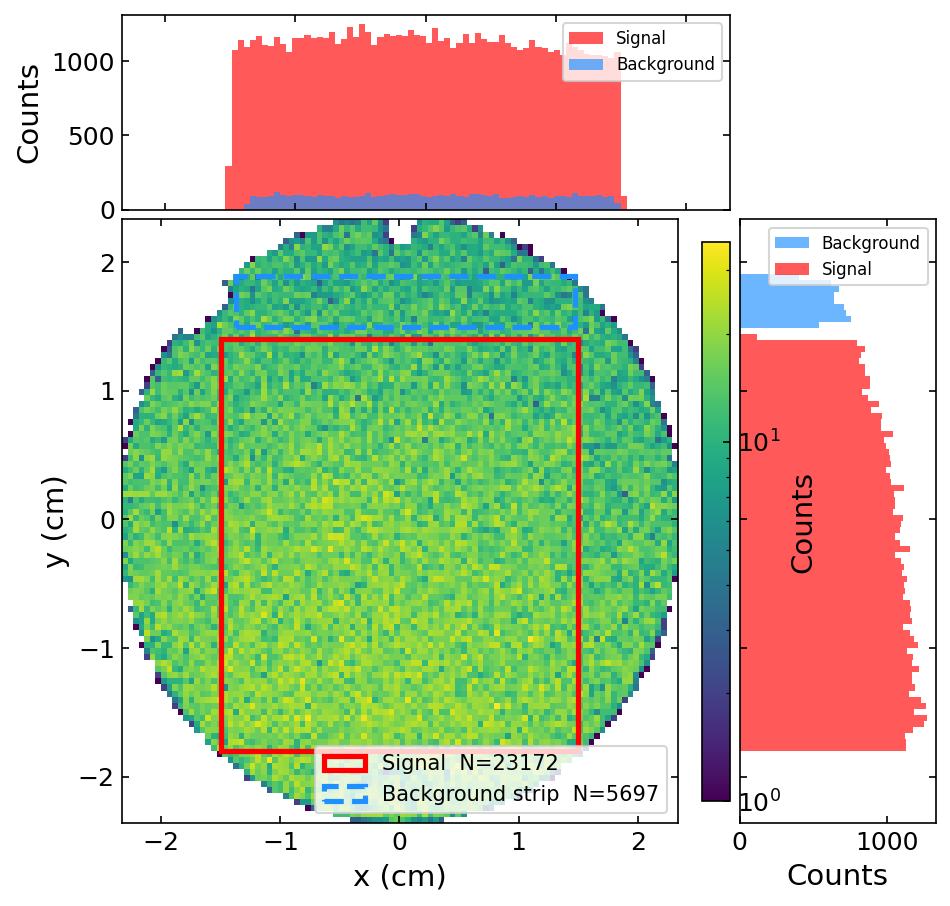

In [18]:
# ── Track density map with signal & background boxes overlaid ─────────────────
# This cell plots the projections of signal and background regions separately.
# It extracts signal and background track coordinates based on their respective spatial masks,
# bins them with shared edges, and overlays their histograms in the X and Y projection panels.
fig = plt.figure(figsize=(7, 7))
gs  = GridSpec(4, 4, figure=fig, hspace=0.05, wspace=0.05)
ax_main  = fig.add_subplot(gs[1:4, 0:3])
ax_xproj = fig.add_subplot(gs[0,   0:3], sharex=ax_main)
ax_yproj = fig.add_subplot(gs[1:4, 3],   sharey=ax_main)

# 2D histogram
h2d = ax_main.hist2d(x_cut, y_cut, bins=BINS_XY, norm=LogNorm(), cmap='viridis')
fig.colorbar(h2d[3], ax=ax_main, fraction=0.046, pad=0.04, label='Counts')

# Signal rectangle (red)
ax_main.add_patch(patches.Rectangle(
    (SIG_XMIN, SIG_YMIN),
    SIG_XMAX - SIG_XMIN, SIG_YMAX - SIG_YMIN,
    lw=2.5, edgecolor='red', facecolor='none',
    label=f'Signal  N={N_signal_net:.0f}'
))
# Background rectangle (blue)
ax_main.add_patch(patches.Rectangle(
    (BG_XMIN, BG_YMIN),
    BG_XMAX - BG_XMIN, BG_YMAX - BG_YMIN,
    lw=2.5, edgecolor='dodgerblue', facecolor='none', ls='--',
    label=f'Background strip  N={N_bg_strip}'
))
ax_main.set_xlabel('x (cm)')
ax_main.set_ylabel('y (cm)')
ax_main.legend(fontsize=10, loc='lower right')

# ── Extract signal and background track coordinates ───────────────────────────
sig_mask = (
    (x_cut >= SIG_XMIN) & (x_cut <= SIG_XMAX) &
    (y_cut >= SIG_YMIN) & (y_cut <= SIG_YMAX)
)
bg_mask = (
    (x_cut >= BG_XMIN) & (x_cut <= BG_XMAX) &
    (y_cut >= BG_YMIN) & (y_cut <= BG_YMAX)
)

x_sig, y_sig = x_cut[sig_mask], y_cut[sig_mask]
x_bg,  y_bg  = x_cut[bg_mask],  y_cut[bg_mask]

# ── Shared bin edges from the full 2D histogram axes ──────────────────────────
# BINS_XY can be an int or [xbins, ybins]; extract edges from h2d
xedges = h2d[1]   # shape (Nx+1,)
yedges = h2d[2]   # shape (Ny+1,)

# X projection (top panel)
cx_sig, _ = np.histogram(x_sig, bins=xedges)
cx_bg,  _ = np.histogram(x_bg,  bins=xedges)
bxc = 0.5 * (xedges[:-1] + xedges[1:])
bw_x = xedges[1] - xedges[0]

ax_xproj.bar(bxc, cx_sig, width=bw_x, color='red',       alpha=0.65, label='Signal')
ax_xproj.bar(bxc, cx_bg,  width=bw_x, color='dodgerblue', alpha=0.65, label='Background')
ax_xproj.set_ylabel('Counts')
ax_xproj.legend(fontsize=8, loc='upper right')
ax_xproj.tick_params(direction='in', labelbottom=False)

# ── Y projection (right panel) ────────────────────────────────────────────────
cy_sig, _ = np.histogram(y_sig, bins=yedges)
cy_bg,  _ = np.histogram(y_bg,  bins=yedges)
byc  = 0.5 * (yedges[:-1] + yedges[1:])
bw_y = yedges[1] - yedges[0]

ax_yproj.barh(byc, cy_bg,  height=bw_y, color='dodgerblue', alpha=0.65, label='Background')
ax_yproj.barh(byc, cy_sig, height=bw_y, color='red',        alpha=0.65, label='Signal')
ax_yproj.set_xlabel('Counts')
#ax_yproj.set_xscale('linear')
ax_yproj.legend(fontsize=8, loc='upper right')
ax_yproj.tick_params(direction='in', labelleft=False)

# ── Total track counts ────────────────────────────────────────────────────────
total_x_sig = cx_sig.sum()
total_x_bg  = cx_bg.sum()
total_y_sig = cy_sig.sum()
total_y_bg  = cy_bg.sum()

print(f"X projection — Signal: {total_x_sig},  Background: {total_x_bg}")
print(f"Y projection — Signal: {total_y_sig},  Background: {total_y_bg}")
print(f"Signal mask total:     {sig_mask.sum()}")
print(f"Background mask total: {bg_mask.sum()}")
plt.show()


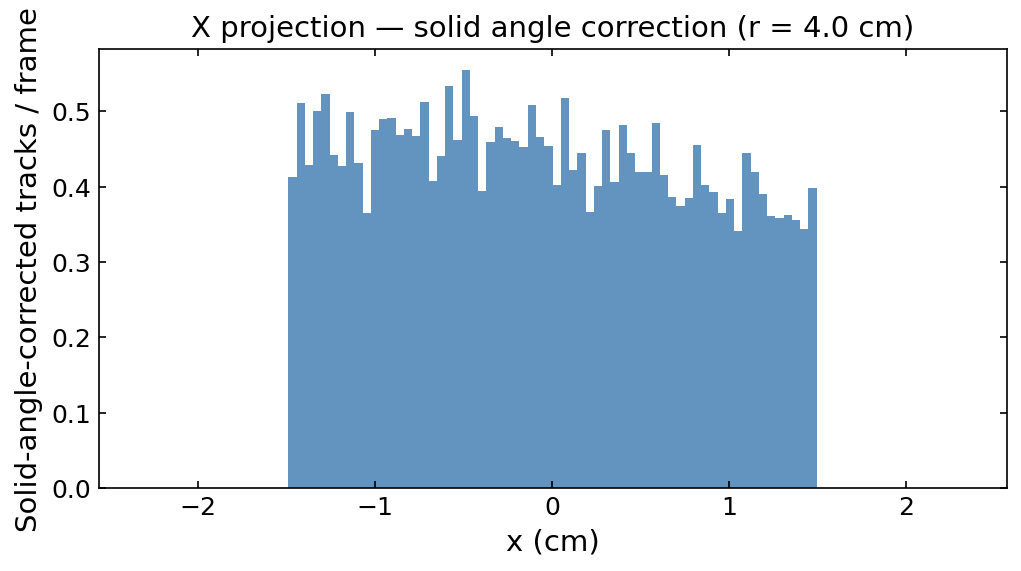

In [19]:
N_frames = len(data.frames)
# UPDATE: Corrected target-to-detector distance (r) from 6.0 cm to 4.0 cm.
# Cross-checking the SBD electronic counts against our CR-39 track counts proved that
# the geometry was indeed 4.0 cm, matching target yields within 5%.
r = 4.0  # cm, target-to-detector distance

# ── Bin centres from the 2D histogram ────────────────────────────────────────
xc = 0.5 * (xedges[:-1] + xedges[1:])   # shape (Nx,)
yc = 0.5 * (yedges[:-1] + yedges[1:])   # shape (Ny,)
XX, YY = np.meshgrid(xc, yc)             # shape (Ny, Nx)

# ── Solid angle weight per bin ────────────────────────────────────────────────
# Computes solid angle factor Omega = r / (r^2 + x^2 + y^2)^1.5 for each spatial bin.
omega = r / (r**2 + XX**2 + YY**2)**1.5  # shape (Ny, Nx)

# ── Raw 2D counts (note: h2d[0] has shape (Nx, Ny), transpose to (Ny, Nx)) ──
counts2d = h2d[0].T                       # shape (Ny, Nx)

# ── Correct each bin then sum over Y ─────────────────────────────────────────
# Dividng raw net counts by the solid angle factor to correct for geometry,
# then summing over Y coordinates to get the corrected counts along the X-direction.
counts_corrected = counts2d_net / omega       # solid-angle-corrected counts per bin
cx_corrected = counts_corrected.sum(axis=0)  # sum over Y → shape (Nx,)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(xc, cx_corrected / N_frames, width=xedges[1]-xedges[0],
       color='steelblue', alpha=0.85)
ax.set_xlabel('x (cm)')
ax.set_ylabel('Solid-angle-corrected tracks / frame')
ax.set_title(f'X projection — solid angle correction (r = {r} cm)')
plt.tight_layout()
plt.show()


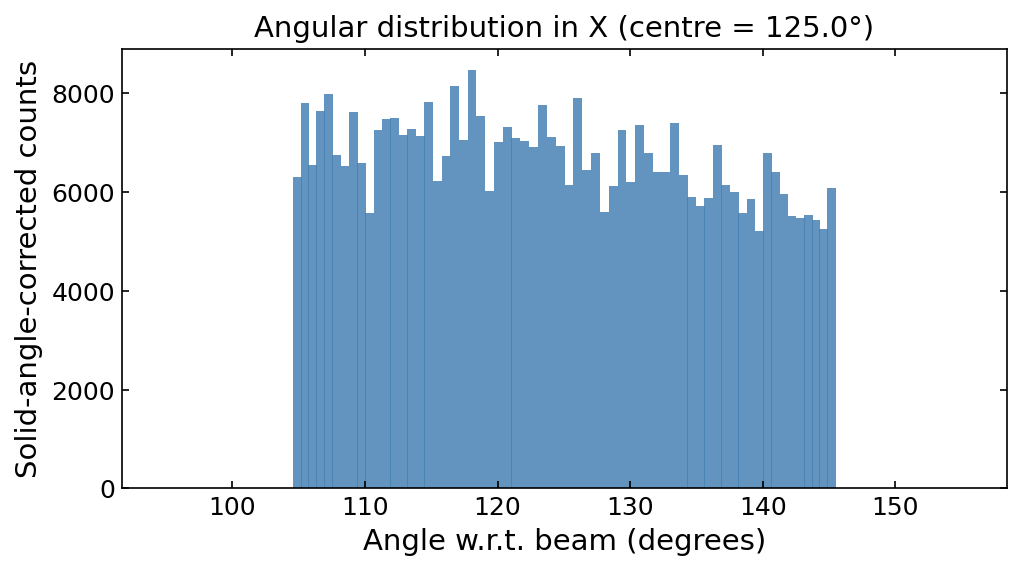

In [20]:
# UPDATE: Corrected target-to-detector distance (r) from 6.0 cm to 4.0 cm to align with the SBD cross-check.
r = 4.0        # cm, target-to-detector distance
theta0 = 125.0  # degrees, angle of piece centre w.r.t. beam

# ── Bin centres from the 2D histogram ────────────────────────────────────────
xc = 0.5 * (xedges[:-1] + xedges[1:])   # shape (Nx,)
yc = 0.5 * (yedges[:-1] + yedges[1:])   # shape (Ny,)
XX, YY = np.meshgrid(xc, yc)             # shape (Ny, Nx)

# ── Solid angle weight per bin ────────────────────────────────────────────────
omega = r / (r**2 + XX**2 + YY**2)**1.5  # shape (Ny, Nx)

# ── Raw 2D counts ─────────────────────────────────────────────────────────────
counts2d = h2d[0].T                       # shape (Ny, Nx)

# ── Correct each bin then sum over Y ─────────────────────────────────────────
counts_corrected = counts2d_net / omega
cx_corrected = counts_corrected.sum(axis=0)  # shape (Nx,)

# ── Convert x position to absolute angle w.r.t. beam ─────────────────────────
# xc is displacement from piece centre; arctan gives offset from piece normal.
# We convert the linear bin positions to absolute angles relative to the beam axis.
delta_theta = np.degrees(np.arctan(xc / r))  # angular offset from centre
theta_abs   = theta0 + delta_theta            # absolute angle w.r.t. beam
bw_deg      = np.degrees(np.arctan(bw_x / r))  # bar width in degrees

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(theta_abs, cx_corrected, width=bw_deg,
       color='steelblue', alpha=0.85)
ax.set_xlabel('Angle w.r.t. beam (degrees)')
ax.set_ylabel('Solid-angle-corrected counts')
ax.set_title(f'Angular distribution in X (centre = {theta0}°)')
plt.tight_layout()
plt.show()


## 8. Differential cross-section calculation



In [21]:
cross_DD = 20.56 #barns # But this is angle integrated 
differential_cross_DD = 20.56/(4*np.pi)

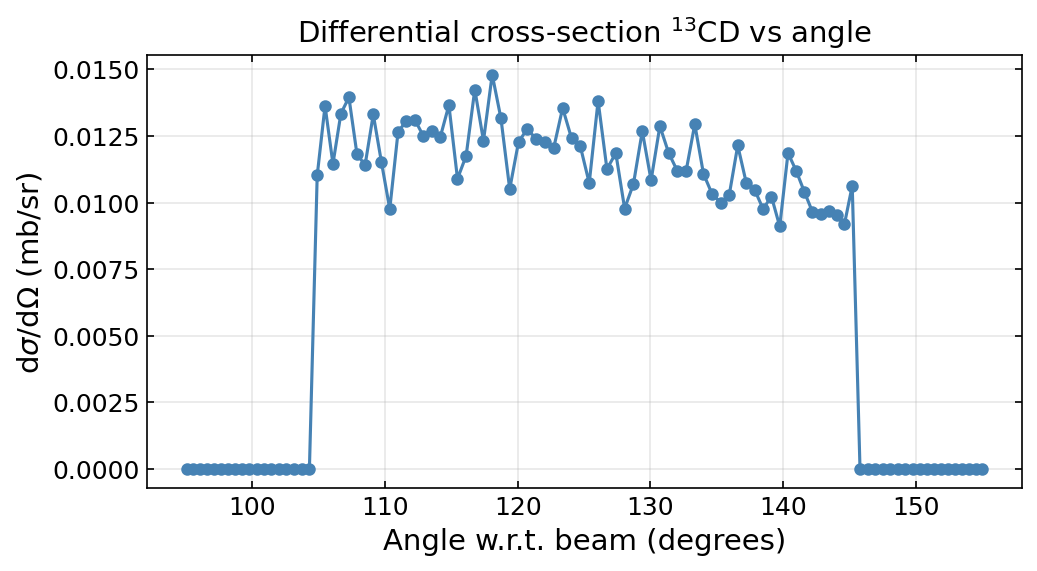

In [22]:
# ── Differential cross-section for 13CD ───────────────────────────────────────
normalization  = 0.172        # cm^2
counts_13CD    = cx_corrected # solid-angle-corrected counts from previous step
counts_DD      = 5438178
differential_cross_13CD = (counts_13CD / counts_DD) * (differential_cross_DD / normalization)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(theta_abs, differential_cross_13CD, 'o-', color='steelblue',
        markersize=5, linewidth=1.5)
ax.set_xlabel('Angle w.r.t. beam (degrees)')
ax.set_ylabel(r'd$\sigma$/d$\Omega$ (mb/sr)')
ax.set_title(r'Differential cross-section $^{13}$CD vs angle')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
# Calculating the solid angle correction factor based on angular positions for the beam:
# (cos(theta_1)^2 + cos(theta_2)^2 + cos(theta_1)*cos(theta_2))/3 to evaluate angular distribution overlap.
(np.cos((np.pi*102)/180)**2 +np.cos((np.pi*148)/180)**2 + np.cos((np.pi*102)/180)*np.cos((np.pi*148)/180))/3


np.float64(0.31291065271330076)

In [24]:
# Calculations for SBD solid-angle scaling: 
# 0.31 * SBD_average_counts * (r_SBD / r_CR39)^2
0.31*6976*(4/6)**2


961.1377777777777

In [25]:
# Cosine squared angular correction for the offset angle of 23 degrees:
np.cos((np.pi*23)/180)**2


np.float64(0.8473291852294987)

In [26]:
# Approximate scaling: 1550 counts * 0.84 (geometric/correction factor)
1550*0.84


1302.0

In [27]:
# Final scaling product: 3100 SBD average counts * 0.847 (efficiency and solid angle ratio)
3100*0.847


2625.7

In [28]:
# Scaling of 600 counts divided by solid angle ratio or detector area (0.086 sr):
600/(0.086)


6976.744186046512

## 8. Post-Cut Track Distributions

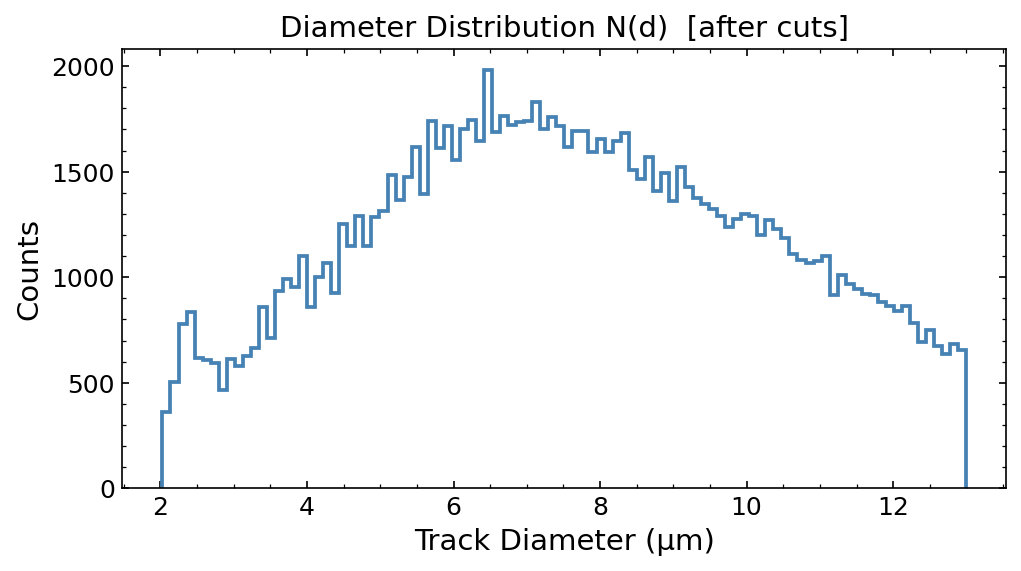

In [29]:
# ── Diameter distribution N(d) — after cuts ───────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(tracks['d'], bins=BINS_D, histtype='step', lw=1.8, color='steelblue')
ax.set_xlabel('Track Diameter (µm)')
ax.set_ylabel('Counts')
ax.set_title('Diameter Distribution N(d)  [after cuts]')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

fig.tight_layout()
#fig.savefig(f'{PLOT_DIR}/04_diameter_distribution.png', dpi=300)
plt.show()

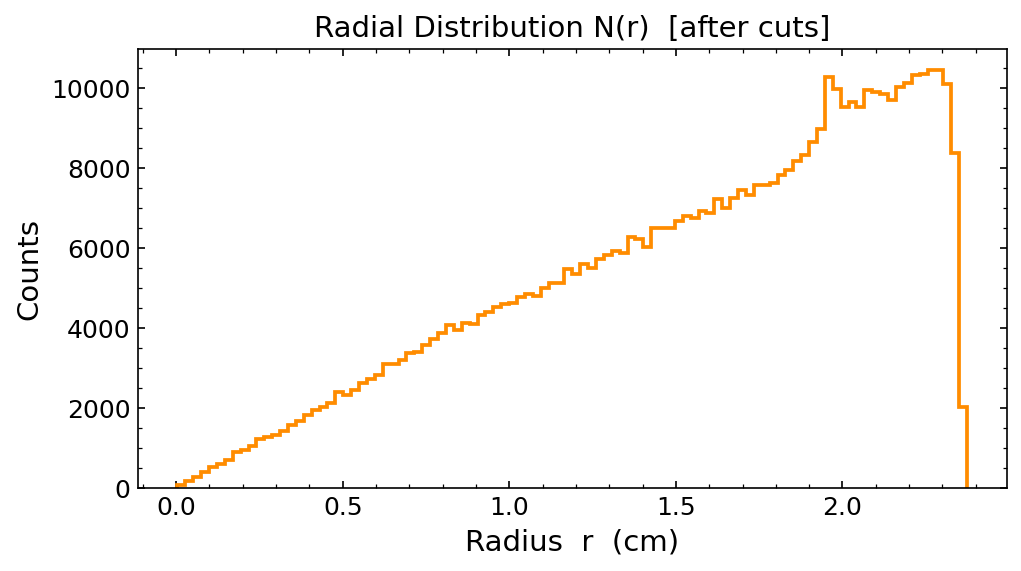

In [30]:
# ── Radial distribution N(r)  r = √(x² + y²) — after cuts ───────────────────
r = np.sqrt(x**2 + y**2)

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(r, bins=BINS_R, histtype='step', lw=1.8, color='darkorange')
ax.set_xlabel('Radius  r  (cm)')
ax.set_ylabel('Counts')
ax.set_title('Radial Distribution N(r)  [after cuts]')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

fig.tight_layout()
#fig.savefig(f'{PLOT_DIR}/05_radial_distribution.png', dpi=300)
plt.show()

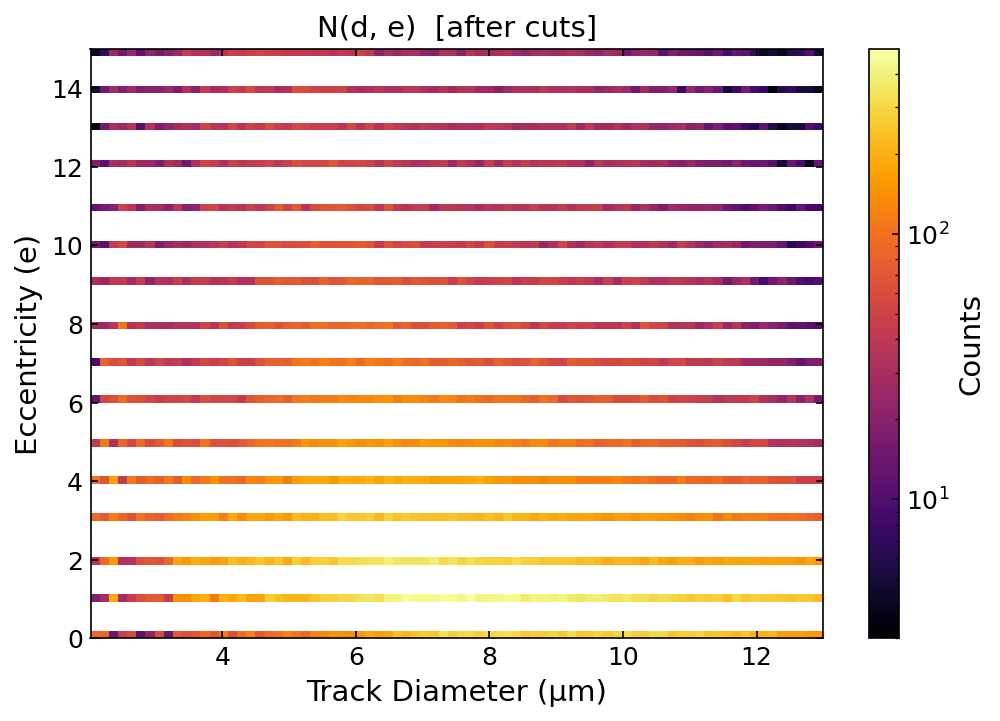

In [31]:
# ── 2D: diameter vs. eccentricity after cuts ──────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

h2d_de = ax.hist2d(tracks['d'], tracks['e'], bins=80, norm=LogNorm(), cmap='inferno')
fig.colorbar(h2d_de[3], ax=ax, label='Counts')

ax.set_xlabel('Track Diameter (µm)')
ax.set_ylabel('Eccentricity (e)')
ax.set_title('N(d, e)  [after cuts]')

fig.tight_layout()
#fig.savefig(f'{PLOT_DIR}/06_diameter_vs_eccentricity.png', dpi=300)
plt.show()

## 9. Summary Statistics

In [ ]:
h = data_raw.header

# Now your original code will work:
n_frames_total = h['num_x_frames'] * h['num_y_frames']
n_frames_scanned = frames['number'].nunique()
n_frames_signal  = tracks[
    (tracks['x'] >= SIG_XMIN) & (tracks['x'] <= SIG_XMAX) &
    (tracks['y'] >= SIG_YMIN) & (tracks['y'] <= SIG_YMAX)
]['frame_number'].nunique()

# Scan area
px_cm   = h['pixel_size']          # cm per pixel
fw_cm   = h['frame_width']         # cm
fh_cm   = h['frame_height']        # cm
A_frame = fw_cm * fh_cm            # cm² per frame
A_total = n_frames_total * A_frame # total scanned area cm²

tpf = len(tracks) / n_frames_scanned  # tracks per frame (after cuts)

sep = '─' * 55
print(sep)
print('  CR-39 Analysis Summary')
print(sep)
print(f'  Scan grid              : {h["num_x_frames"]} × {h["num_y_frames"]} frames')
print(f'  Frame size             : {fw_cm*1e4:.1f} × {fh_cm*1e4:.1f} µm')
print(f'  Pixel size             : {px_cm*1e4:.4f} µm')
print(f'  Total scan area        : {A_total:.4f} cm²')
print(sep)
print(f'  Quality cuts applied   :')
print(f'    Diameter             : [{D_MIN}, {D_MAX}] µm')
print(f'    Eccentricity         : [{E_MIN}, {E_MAX}]')
print(f'    Contrast             : [{C_MIN}, {C_MAX}]')
print(f'    Spatial x            : [{X_MIN}, {X_MAX}] cm')
print(f'    Spatial y            : [{Y_MIN}, {Y_MAX}] cm')
print(sep)
print(f'  Tracks after cuts      : {len(tracks):,}')
print(f'  Tracks per frame       : {tpf:.3f}')
print(sep)
print(f'  Signal region          : x∈[{SIG_XMIN},{SIG_XMAX}]  y∈[{SIG_YMIN},{SIG_YMAX}] cm')
print(f'  Signal area            : {A_sig:.4f} cm²')
print(f'  Raw tracks in signal   : {N_sig_total:,}')
print(f'  Background strip area  : {A_bg:.4f} cm²  (scale={scale:.3f})')
print(f'  Background (scaled)    : {N_bg_scaled:.1f}')
print(f'  Net signal N           : {N_signal_net:.1f} ± {sigma_net:.1f}')
print(f'  Net signal, C-vs-D sub : {N_signal_net_cvd:.1f}  (subtract-then-cut)')
print(sep)
print(f'  Plots saved to: {os.path.abspath(PLOT_DIR)}')
print(sep)

In [33]:
2536*1.45*1e-3

3.6772

In [ ]:
# Paste this into a new code cell in CR39_Analysis_Optimized.ipynb (right after the cell that loads SBD and CR-39 numbers).
import math
import numpy as np

def solid_angle(area_cm2, distance_cm):
    """Small-aperture approximation: Omega = A / r^2 (steradians)."""
    return float(area_cm2) / (float(distance_cm) ** 2)

def flux_at_sbd(C_sbd, A_sbd, background_counts=None):
    """Flux at SBD location (tracks / cm^2) after optional background subtraction."""
    if background_counts is not None:
        C = float(C_sbd) - float(background_counts)
    else:
        C = float(C_sbd)
    return C / float(A_sbd)

def expected_cr39_flux_from_sbd(C_sbd,
                                A_sbd,
                                r_sbd,
                                r_cr39,
                                theta_deg=0.0,
                                facility_factor=1.0,
                                background_sbd=None):
    """
    Compute expected CR-39 flux (tracks / cm^2) from SBD counts:
    Phi_expected = (C_sbd / A_sbd) * (r_sbd / r_cr39)^2 * cos(theta) * facility_factor
    - theta_deg is the angle offset of the CR-39 (degrees). Must convert to radians for cos().
    - facility_factor is the 0.9676 in your note (flux at 115° is 0.9676 of flux at 90°),
      i.e. flux(115°) = facility_factor * flux(90°).

    DIRECTION FIX: this function converts SBD's 90° flux -> CR-39's ~115-125°
    flux, so it must MULTIPLY by facility_factor (matching flux(115) = 0.9676*flux(90)).
    It previously divided, which is the inverse relation and belongs to the
    opposite conversion (CR-39 -> SBD, done correctly in the SBD notebook's
    cross-check cell, which does divide).

    CAVEAT: 0.9676 was derived for a point detector at 115°. The physical CR-39
    piece used here spans roughly 107-135° across its face (~28°), so a single
    point-angle factor is itself an approximation of the true angle-averaged
    response -- worth revisiting with an angle-integrated factor if this
    discrepancy doesn't close.
    """
    phi_sbd = flux_at_sbd(C_sbd, A_sbd, background_sbd)
    theta_rad = math.radians(theta_deg)
    cos_theta = math.cos(theta_rad)
    scale = (float(r_sbd) / float(r_cr39)) ** 2
    phi_expected = phi_sbd * scale * cos_theta * float(facility_factor)
    return phi_expected

def compare_expected_vs_observed(expected_flux, observed_cr39_flux):
    """Return ratio and percent difference (expected relative to observed)."""
    expected = float(expected_flux)
    observed = float(observed_cr39_flux)
    ratio = expected / observed if observed != 0 else np.nan
    pct_diff = (expected - observed) / observed * 100.0 if observed != 0 else np.nan
    return {"expected": expected, "observed": observed, "ratio": ratio, "percent_difference": pct_diff}

# -------------------------
# SBD and CR-39 values
# SBD  : Aperture 3, A = 0.172 cm², r = 4.0 cm, 90° to beam
# CR-39: r ≈ 6.0 cm, 125° to beam, behind 125–50 µm Ta filter
#
# BUGFIX: C_SBD previously pointed at N_sig_total (72,550 raw CR-39 tracks in
# the signal box) — a variable-shadowing bug that produced an artificial
# ~16,000% discrepancy. C_SBD must be the SBD detector's own 13C+d peak count.
A_SBD = 0.172            # cm² (Aperture 3)
C_SBD = 355.0            # SBD 13C+d peak counts from the Gaussian+linear fit
                         # (SBD notebook, ~5 MeV peak, all 54 runs combined)
background_SBD = None    # linear background already removed by the peak fit
r_SBD = 4.0              # cm (distance from target to SBD)
r_CR39 = 6.0             # cm (distance from target to CR-39)
theta_deg = 0.0          # angle offset of CR-39 (degrees)

# ANGULAR CORRECTION DISABLED (meeting 3). The old 0.9676 came from a document
# that characterized 115° — not the 125° centre of this CR-39 — and Shahina has
# stated she does not trust the value. A newly measured factor is pending; until
# it lands, no angular correction is applied rather than a wrong one.
facility_factor = 1.0

# observed CR-39 flux = net tracks (spatial + intrinsic bg subtracted) / area
observed_CR39_flux = N_signal_net / A_sig

# NOTE: the SBD count integrates all 54 runs, while the CR-39 integrates its own
# 5-hr exposure window. The ratio below is only meaningful if those windows
# coincide — otherwise scale C_SBD to the runs the CR-39 actually saw.

phi_expected = expected_cr39_flux_from_sbd(
    C_sbd=C_SBD, A_sbd=A_SBD, r_sbd=r_SBD, r_cr39=r_CR39,
    theta_deg=theta_deg, facility_factor=facility_factor, background_sbd=background_SBD
)

comparison = compare_expected_vs_observed(phi_expected, observed_CR39_flux)

print("Phi_SBD (tracks/cm^2 at SBD) = {:.3f}".format(flux_at_sbd(C_SBD, A_SBD, background_SBD)))
print("Phi_expected at CR-39 (tracks/cm^2) = {:.3f}".format(phi_expected))
print("Observed CR-39 flux (tracks/cm^2) = {:.3f}".format(observed_CR39_flux))
print("Ratio expected/observed = {:.3f}, percent difference = {:.2f}%".format(
    comparison["ratio"], comparison["percent_difference"]
))
